In [ ]:
import pandas as pd
import numpy as np
import os

files_needed = [
    '/content/NDQ06.20260311T110331.csv',
    '/content/BHQ17.20260311T110341.csv',
    '/content/commencements_residential_filtered.csv',
    '/content/FY001.20260311T120338.csv',
    '/content/FY003B.20260311T120318.csv',
    '/content/PEA04.20260311T120350.csv',
    '/content/RAA02.20260311T120342.csv',
    '/content/RIQ02.20260311T120343.csv',
    '/content/HPM09.20260311T120347.csv',
]

print("Checking files...")
all_found = True
for f in files_needed:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✅ {f} ({size:.0f} KB)")
    else:
        print(f"  ❌ MISSING: {f}")
        all_found = False

if all_found:
    print("\nAll 9 files found. Ready to proceed.")
else:
    print("\nSome files missing. Upload them using the sidebar.")

Checking files...
  ✅ /content/NDQ06.20260311T110331.csv (674 KB)
  ✅ /content/BHQ17.20260311T110341.csv (10535 KB)
  ✅ /content/commencements_residential_filtered.csv (7028 KB)
  ✅ /content/FY001.20260311T120338.csv (149 KB)
  ✅ /content/FY003B.20260311T120318.csv (82 KB)
  ✅ /content/PEA04.20260311T120350.csv (777 KB)
  ✅ /content/RAA02.20260311T120342.csv (1143 KB)
  ✅ /content/RIQ02.20260311T120343.csv (3568 KB)
  ✅ /content/HPM09.20260311T120347.csv (2301 KB)

All 9 files found. Ready to proceed.


In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'commencements_residential_filtered.csv', 'FY003B.20260311T120318.csv', 'BHQ17.20260311T110341.csv', 'HPM09.20260311T120347.csv', 'IIA01.20260311T120348.csv', 'HSQ06.20260311T120347.csv', 'RAA02.20260311T120342.csv', 'PEA04.20260311T120350.csv', 'NDQ06.20260311T110331.csv', 'FY003B.20260311T120313.csv', 'CPM06.20260311T120332.csv', 'HSM12.20260311T120340.csv', 'NDQ07.20260311T110346.csv', 'HSM13.20260311T120313.csv', 'RIQ02.20260311T120343.csv', 'FY001.20260311T120338.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# CELL 2: Clean NDQ06 — Completions (TARGET VARIABLE)
# ============================================================

LA_TO_COUNTY = {
    'Carlow County Council': 'Carlow',
    'Cavan County Council': 'Cavan',
    'Clare County Council': 'Clare',
    'Cork City Council': 'Cork',
    'Cork County Council': 'Cork',
    'Donegal County Council': 'Donegal',
    'Dublin City Council': 'Dublin',
    'Dún Laoghaire Rathdown County Council': 'Dublin',
    'Fingal County Council': 'Dublin',
    'South Dublin County Council': 'Dublin',
    'Galway City Council': 'Galway',
    'Galway County Council': 'Galway',
    'Kerry County Council': 'Kerry',
    'Kildare County Council': 'Kildare',
    'Kilkenny County Council': 'Kilkenny',
    'Laois County Council': 'Laois',
    'Leitrim County Council': 'Leitrim',
    'Limerick City & County Council': 'Limerick',
    'Longford County Council': 'Longford',
    'Louth County Council': 'Louth',
    'Mayo County Council': 'Mayo',
    'Mayo  County Council': 'Mayo',
    'Meath County Council': 'Meath',
    'Monaghan County Council': 'Monaghan',
    'Offaly County Council': 'Offaly',
    'Roscommon County Council': 'Roscommon',
    'Sligo County Council': 'Sligo',
    'Tipperary County Council': 'Tipperary',
    'Waterford City & County Council': 'Waterford',
    'Westmeath County Council': 'Westmeath',
    'Wexford County Council': 'Wexford',
    'Wicklow County Council': 'Wicklow',
}

def parse_quarter(q):
    year = int(q[:4])
    quarter = int(q[-1])
    month = (quarter - 1) * 3 + 1
    return pd.Timestamp(year=year, month=month, day=1)

ndq06 = pd.read_csv('/content/NDQ06.20260311T110331.csv')
ndq06 = ndq06[ndq06['Local Authority'] != 'Ireland']
ndq06 = ndq06[ndq06['Local Authority'].isin(LA_TO_COUNTY.keys())]
ndq06['county'] = ndq06['Local Authority'].map(LA_TO_COUNTY)
ndq06['VALUE'] = pd.to_numeric(ndq06['VALUE'], errors='coerce').fillna(0)
ndq06['date'] = ndq06['Quarter'].apply(parse_quarter)

completions = ndq06.groupby(['county', 'date'])['VALUE'].sum().reset_index()
completions.columns = ['county', 'date', 'completions']

print(f"✅ Completions: {completions.shape[0]} rows, {completions['county'].nunique()} counties")
print(f"   Date range: {completions['date'].min()} to {completions['date'].max()}")
print(completions.head())

✅ Completions: 1560 rows, 26 counties
   Date range: 2011-01-01 00:00:00 to 2025-10-01 00:00:00
   county       date  completions
0  Carlow 2011-01-01           34
1  Carlow 2011-04-01           48
2  Carlow 2011-07-01           48
3  Carlow 2011-10-01           76
4  Carlow 2012-01-01           34


In [ ]:
# ============================================================
# CELL 3 (FINAL): Clean BHQ17 — Planning Permission Units
# ============================================================
# Data only available from 2018Q1 onwards in this file.
# We use "Units for which Permission Granted" — the most accurate measure.

bhq17 = pd.read_csv('/content/BHQ17.20260311T110341.csv')
bhq17 = bhq17[bhq17['Statistic Label'] == 'Units for which Permission Granted']
bhq17 = bhq17[bhq17['County'] != 'Ireland']
bhq17 = bhq17[bhq17['County'].isin(LA_TO_COUNTY.keys())]
bhq17 = bhq17[bhq17['Type of Dwelling'].isin(['All houses', 'Apartments'])]
bhq17['county'] = bhq17['County'].map(LA_TO_COUNTY)
bhq17['VALUE'] = pd.to_numeric(bhq17['VALUE'], errors='coerce')
bhq17['date'] = bhq17['Quarter'].apply(parse_quarter)

# Drop NaN values (removes pre-2018 empty rows)
bhq17 = bhq17.dropna(subset=['VALUE'])

permissions = bhq17.groupby(['county', 'date'])['VALUE'].sum().reset_index()
permissions.columns = ['county', 'date', 'permissions']

print(f"✅ Permissions: {permissions.shape[0]} rows, {permissions['county'].nunique()} counties")
print(f"   Date range: {permissions['date'].min()} to {permissions['date'].max()}")
print()
print("Carlow sample:")
print(permissions[permissions['county'] == 'Carlow'].head(5).to_string())
print()
print("Dublin sample:")
print(permissions[permissions['county'] == 'Dublin'].head(5).to_string())

✅ Permissions: 806 rows, 26 counties
   Date range: 2018-01-01 00:00:00 to 2025-07-01 00:00:00

Carlow sample:
   county       date  permissions
0  Carlow 2018-01-01         20.0
1  Carlow 2018-04-01         14.0
2  Carlow 2018-07-01         34.0
3  Carlow 2018-10-01         42.0
4  Carlow 2019-01-01         38.0

Dublin sample:
     county       date  permissions
155  Dublin 2018-01-01       2730.0
156  Dublin 2018-04-01       1288.0
157  Dublin 2018-07-01       3358.0
158  Dublin 2018-10-01       1781.0
159  Dublin 2019-01-01       2016.0


In [ ]:
# ============================================================
# CELL 4: Clean BCMS — Commencement Notices (2014–2026)
# ============================================================

BCMS_LA_TO_COUNTY = {
    'Carlow County Council': 'Carlow',
    'Cavan County Council': 'Cavan',
    'Clare County Council': 'Clare',
    'Cork City Council': 'Cork',
    'Cork County Council': 'Cork',
    'Donegal County Council': 'Donegal',
    'Dublin City Council': 'Dublin',
    'Dún-Laoghaire Rathdown County Council': 'Dublin',
    'Fingal County Council': 'Dublin',
    'South Dublin County Council': 'Dublin',
    'Galway City Council': 'Galway',
    'Galway County Council': 'Galway',
    'Kerry County Council': 'Kerry',
    'Kildare County Council': 'Kildare',
    'Kilkenny County Council': 'Kilkenny',
    'Laois County Council': 'Laois',
    'Leitrim County Council': 'Leitrim',
    'Limerick City and County Council': 'Limerick',
    'Longford County Council': 'Longford',
    'Louth County Council': 'Louth',
    'Mayo County Council': 'Mayo',
    'Meath County Council': 'Meath',
    'Monaghan County Council': 'Monaghan',
    'Offaly County Council': 'Offaly',
    'Roscommon County Council': 'Roscommon',
    'Sligo County Council': 'Sligo',
    'Tipperary County Council': 'Tipperary',
    'Waterford City and County Council': 'Waterford',
    'Westmeath County Council': 'Westmeath',
    'Wexford County Council': 'Wexford',
    'Wicklow County Council': 'Wicklow',
}

bcms = pd.read_csv('/content/commencements_residential_filtered.csv')
bcms = bcms[bcms['LocalAuthority'].isin(BCMS_LA_TO_COUNTY.keys())]
bcms['county'] = bcms['LocalAuthority'].map(BCMS_LA_TO_COUNTY)
bcms['CN_Units_for_phase'] = pd.to_numeric(bcms['CN_Units_for_phase'], errors='coerce').fillna(0)
bcms['date'] = pd.to_datetime(bcms['CN_Commencement_Date'])
bcms['quarter_date'] = bcms['date'].dt.to_period('Q').dt.to_timestamp()

# Filter to 2014 onwards (before that data is unreliable)
bcms = bcms[bcms['quarter_date'] >= '2014-01-01']
bcms = bcms[bcms['quarter_date'] <= '2025-12-31']

commencements = bcms.groupby(['county', 'quarter_date'])['CN_Units_for_phase'].sum().reset_index()
commencements.columns = ['county', 'date', 'commencements']

print(f"✅ Commencements: {commencements.shape[0]} rows, {commencements['county'].nunique()} counties")
print(f"   Date range: {commencements['date'].min()} to {commencements['date'].max()}")
print()
print("Carlow sample:")
print(commencements[commencements['county'] == 'Carlow'].head(5).to_string())
print()
print("Dublin sample:")
print(commencements[commencements['county'] == 'Dublin'].head(5).to_string())

✅ Commencements: 1222 rows, 26 counties
   Date range: 2014-01-01 00:00:00 to 2025-10-01 00:00:00

Carlow sample:
   county       date  commencements
0  Carlow 2014-04-01           20.0
1  Carlow 2014-07-01            6.0
2  Carlow 2014-10-01            8.0
3  Carlow 2015-01-01            8.0
4  Carlow 2015-04-01           27.0

Dublin sample:
     county       date  commencements
236  Dublin 2014-04-01          164.0
237  Dublin 2014-07-01         1580.0
238  Dublin 2014-10-01         1897.0
239  Dublin 2015-01-01         1400.0
240  Dublin 2015-04-01         6036.0


In [ ]:
# ============================================================
# CELL 5: Clean FY001 + FY003B — Census Population
# ============================================================

FY003B_TO_COUNTY = {
    'Carlow': 'Carlow', 'Cavan': 'Cavan', 'Clare': 'Clare',
    'Cork City': 'Cork', 'Cork County': 'Cork',
    'Donegal': 'Donegal',
    'Dublin City': 'Dublin', 'Dún Laoghaire-Rathdown': 'Dublin',
    'Fingal': 'Dublin', 'South Dublin': 'Dublin',
    'Galway City': 'Galway', 'Galway County': 'Galway',
    'Kerry': 'Kerry', 'Kildare': 'Kildare', 'Kilkenny': 'Kilkenny',
    'Laois': 'Laois', 'Leitrim': 'Leitrim',
    'Limerick City': 'Limerick', 'Limerick County': 'Limerick',
    'Limerick City and County': 'Limerick',
    'Longford': 'Longford', 'Louth': 'Louth',
    'Mayo': 'Mayo', 'Meath': 'Meath', 'Monaghan': 'Monaghan',
    'Offaly': 'Offaly', 'Roscommon': 'Roscommon', 'Sligo': 'Sligo',
    'North Tipperary': 'Tipperary', 'South Tipperary': 'Tipperary',
    'Tipperary': 'Tipperary',
    'Waterford City': 'Waterford', 'Waterford County': 'Waterford',
    'Waterford City and County': 'Waterford',
    'Westmeath': 'Westmeath', 'Wexford': 'Wexford', 'Wicklow': 'Wicklow',
}

STANDARD_COUNTIES = [
    'Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal', 'Dublin',
    'Galway', 'Kerry', 'Kildare', 'Kilkenny', 'Laois', 'Leitrim',
    'Limerick', 'Longford', 'Louth', 'Mayo', 'Meath', 'Monaghan',
    'Offaly', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford',
    'Westmeath', 'Wexford', 'Wicklow'
]

# FY001: Simple county names, census years
fy001 = pd.read_csv('/content/FY001.20260311T120338.csv')
fy001 = fy001[fy001['Sex'] == 'Both sexes']
fy001 = fy001[fy001['County'].isin(STANDARD_COUNTIES)]
fy001['VALUE'] = pd.to_numeric(fy001['VALUE'], errors='coerce')
fy001['CensusYear'] = pd.to_numeric(fy001['CensusYear'], errors='coerce')
fy001 = fy001[fy001['CensusYear'].isin([2006, 2011, 2016, 2022])]
pop_fy001 = fy001.groupby(['County', 'CensusYear'])['VALUE'].sum().reset_index()
pop_fy001.columns = ['county', 'year', 'population']

# FY003B: Has city/county splits — aggregate to county
fy003b = pd.read_csv('/content/FY003B.20260311T120318.csv')
fy003b = fy003b[fy003b['Sex'] == 'Both sexes']
fy003b = fy003b[fy003b['Statistic Label'] == 'Population']
fy003b = fy003b[~fy003b['County and City'].isin(['State'])]
fy003b['county'] = fy003b['County and City'].map(FY003B_TO_COUNTY)
fy003b = fy003b.dropna(subset=['county'])
fy003b['VALUE'] = pd.to_numeric(fy003b['VALUE'], errors='coerce')
fy003b['CensusYear'] = pd.to_numeric(fy003b['CensusYear'], errors='coerce')
pop_fy003b = fy003b.groupby(['county', 'CensusYear'])['VALUE'].sum().reset_index()
pop_fy003b.columns = ['county', 'year', 'population']

# Combine — prefer FY003B where available (more detailed city splits)
pop_combined = pd.concat([pop_fy001, pop_fy003b]).drop_duplicates(
    subset=['county', 'year'], keep='last'
).sort_values(['county', 'year'])

# Interpolate to quarterly for each county
population_quarterly = []
for county in STANDARD_COUNTIES:
    county_pop = pop_combined[pop_combined['county'] == county].copy()
    if len(county_pop) < 2:
        continue
    county_pop = county_pop.set_index('year')['population']
    full_years = range(2011, 2026)
    county_annual = county_pop.reindex(full_years).interpolate(method='linear')

    for year in full_years:
        if pd.isna(county_annual.get(year)):
            continue
        for q_month in [1, 4, 7, 10]:
            population_quarterly.append({
                'county': county,
                'date': pd.Timestamp(year=year, month=q_month, day=1),
                'population': county_annual[year]
            })

population = pd.DataFrame(population_quarterly)

print(f"✅ Population: {population.shape[0]} rows, {population['county'].nunique()} counties")
print(f"   Date range: {population['date'].min()} to {population['date'].max()}")
print()
print("Dublin sample:")
print(population[population['county'] == 'Dublin'].head(5).to_string())
print()
print("Leitrim sample:")
print(population[population['county'] == 'Leitrim'].head(5).to_string())

✅ Population: 1560 rows, 26 counties
   Date range: 2011-01-01 00:00:00 to 2025-10-01 00:00:00

Dublin sample:
     county       date  population
300  Dublin 2011-01-01   1273069.0
301  Dublin 2011-04-01   1273069.0
302  Dublin 2011-07-01   1273069.0
303  Dublin 2011-10-01   1273069.0
304  Dublin 2012-01-01   1287927.0

Leitrim sample:
      county       date  population
660  Leitrim 2011-01-01     31798.0
661  Leitrim 2011-04-01     31798.0
662  Leitrim 2011-07-01     31798.0
663  Leitrim 2011-10-01     31798.0
664  Leitrim 2012-01-01     31847.2


In [ ]:
# ============================================================
# CELL 6: Clean RAA02 — Household Income by County
# ============================================================

RAA02_TO_COUNTY = {f'Co. {c}': c for c in STANDARD_COUNTIES}

raa02 = pd.read_csv('/content/RAA02.20260311T120342.csv')
raa02 = raa02[raa02['Statistic Label'] == 'Disposable Income per Person']
raa02 = raa02[raa02['County'] != 'Ireland']
raa02['county'] = raa02['County'].map(RAA02_TO_COUNTY)
raa02 = raa02.dropna(subset=['county'])
raa02['VALUE'] = pd.to_numeric(raa02['VALUE'], errors='coerce')
raa02['Year'] = pd.to_numeric(raa02['Year'], errors='coerce')
raa02 = raa02[raa02['Year'] >= 2011]
raa02 = raa02.dropna(subset=['VALUE'])

# Expand annual to quarterly
income_quarterly = []
for _, row in raa02.iterrows():
    for q_month in [1, 4, 7, 10]:
        income_quarterly.append({
            'county': row['county'],
            'date': pd.Timestamp(year=int(row['Year']), month=q_month, day=1),
            'income_per_person': row['VALUE']
        })

income = pd.DataFrame(income_quarterly)

print(f"✅ Income: {income.shape[0]} rows, {income['county'].nunique()} counties")
print(f"   Date range: {income['date'].min()} to {income['date'].max()}")
print()
print("Dublin sample:")
print(income[income['county'] == 'Dublin'].head(5).to_string())

✅ Income: 1456 rows, 26 counties
   Date range: 2011-01-01 00:00:00 to 2024-10-01 00:00:00

Dublin sample:
     county       date  income_per_person
20   Dublin 2011-01-01       18659.077496
21   Dublin 2011-04-01       18659.077496
22   Dublin 2011-07-01       18659.077496
23   Dublin 2011-10-01       18659.077496
124  Dublin 2012-01-01       18962.566542


In [ ]:
# ============================================================
# CELL 7: Clean RIQ02 — RTB Rent Index by County
# ============================================================

riq02 = pd.read_csv('/content/RIQ02.20260311T120343.csv')
riq02 = riq02[riq02['Number of Bedrooms'] == 'All bedrooms']
riq02 = riq02[riq02['Property Type'] == 'All property types']
riq02 = riq02[riq02['Location'].isin(STANDARD_COUNTIES)]
riq02['county'] = riq02['Location']
riq02['VALUE'] = pd.to_numeric(riq02['VALUE'], errors='coerce')
riq02['date'] = riq02['Quarter'].apply(parse_quarter)
riq02 = riq02[riq02['date'] >= '2011-01-01']
riq02 = riq02.dropna(subset=['VALUE'])

rents = riq02[['county', 'date', 'VALUE']].copy()
rents.columns = ['county', 'date', 'avg_rent']

print(f"✅ Rents: {rents.shape[0]} rows, {rents['county'].nunique()} counties")
print(f"   Date range: {rents['date'].min()} to {rents['date'].max()}")
print()
print("Dublin sample:")
print(rents[rents['county'] == 'Dublin'].head(5).to_string())
print()
print("Galway sample:")
print(rents[rents['county'] == 'Galway'].head(5).to_string())

✅ Rents: 1508 rows, 26 counties
   Date range: 2011-01-01 00:00:00 to 2025-04-01 00:00:00

Dublin sample:
      county       date  avg_rent
5869  Dublin 2011-01-01   1005.92
6315  Dublin 2011-04-01   1001.69
6761  Dublin 2011-07-01   1010.07
7207  Dublin 2011-10-01   1012.26
7653  Dublin 2012-01-01   1015.16

Galway sample:
      county       date  avg_rent
6036  Galway 2011-01-01    709.66
6482  Galway 2011-04-01    700.50
6928  Galway 2011-07-01    728.84
7374  Galway 2011-10-01    727.08
7820  Galway 2012-01-01    704.76


In [ ]:
# ============================================================
# CELL 8: Clean HPM09 — Property Price Index (National)
# ============================================================

hpm09 = pd.read_csv('/content/HPM09.20260311T120347.csv')
hpm09 = hpm09[hpm09['Type of Residential Property'] == 'National - all residential properties']
hpm09['VALUE'] = pd.to_numeric(hpm09['VALUE'], errors='coerce')
hpm09['month_date'] = pd.to_datetime(hpm09['Month'], format='%Y %B')
hpm09 = hpm09.dropna(subset=['VALUE', 'month_date'])
hpm09['date'] = hpm09['month_date'].dt.to_period('Q').dt.to_timestamp()
hpm09 = hpm09[hpm09['date'] >= '2011-01-01']

price_index = hpm09.groupby('date')['VALUE'].mean().reset_index()
price_index.columns = ['date', 'property_price_index']

print(f"✅ Property Price Index: {price_index.shape[0]} rows")
print(f"   Date range: {price_index['date'].min()} to {price_index['date'].max()}")
print()
print(price_index.head())

✅ Property Price Index: 60 rows
   Date range: 2011-01-01 00:00:00 to 2025-10-01 00:00:00

        date  property_price_index
0 2011-01-01             18.700000
1 2011-04-01             16.958333
2 2011-07-01             14.583333
3 2011-10-01             13.383333
4 2012-01-01             12.875000


In [ ]:
# ============================================================
# CELL 9: MERGE ALL INTO MASTER DATASET
# ============================================================

# Start with completions (has the full county × quarter grid)
master = completions.copy()
print(f"Start with completions: {master.shape}")

# Merge permissions (2018+ only — earlier quarters will be NaN, that's fine)
master = master.merge(permissions, on=['county', 'date'], how='left')
print(f"+ permissions: {master.shape}")

# Merge commencements (2014+ only)
master = master.merge(commencements, on=['county', 'date'], how='left')
print(f"+ commencements: {master.shape}")

# Merge population
master = master.merge(population, on=['county', 'date'], how='left')
print(f"+ population: {master.shape}")

# Merge income
master = master.merge(income, on=['county', 'date'], how='left')
print(f"+ income: {master.shape}")

# Merge rents
master = master.merge(rents, on=['county', 'date'], how='left')
print(f"+ rents: {master.shape}")

# Merge property price index (national — no county column)
master = master.merge(price_index, on='date', how='left')
print(f"+ property price index: {master.shape}")

# Sort
master = master.sort_values(['county', 'date']).reset_index(drop=True)

# ============================================================
# FEATURE ENGINEERING
# ============================================================
print("\nAdding features...")

# Lagged features per county
for lag in [1, 2, 3, 4, 5, 6]:
    master[f'permissions_lag{lag}'] = master.groupby('county')['permissions'].shift(lag)
    master[f'commencements_lag{lag}'] = master.groupby('county')['commencements'].shift(lag)
    master[f'completions_lag{lag}'] = master.groupby('county')['completions'].shift(lag)

# Year-over-year growth rates
master['income_growth'] = master.groupby('county')['income_per_person'].pct_change(4)
master['rent_growth'] = master.groupby('county')['avg_rent'].pct_change(4)
master['population_growth'] = master.groupby('county')['population'].pct_change(4)

# Pipeline conversion rate
master['perm_to_comp_rate'] = np.where(
    master['permissions_lag4'] > 0,
    master['completions'] / master['permissions_lag4'],
    np.nan
)

# Quarter number (seasonality)
master['quarter_num'] = master['date'].dt.quarter

# Completions per 1000 population (annualised)
master['completions_per_1000'] = np.where(
    master['population'] > 0,
    master['completions'] / master['population'] * 1000 * 4,
    np.nan
)

# Year column
master['year'] = master['date'].dt.year

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"MASTER DATASET READY")
print(f"{'='*60}")
print(f"Shape: {master.shape[0]} rows × {master.shape[1]} columns")
print(f"Counties: {master['county'].nunique()}")
print(f"Date range: {master['date'].min()} to {master['date'].max()}")
print(f"\nColumn coverage:")
for col in ['completions', 'permissions', 'commencements', 'population',
            'income_per_person', 'avg_rent', 'property_price_index']:
    pct = master[col].notna().mean() * 100
    print(f"  {col:25s} {pct:.1f}% non-null")

# Save
master.to_csv('/content/master_dataset.csv', index=False)
print(f"\n✅ Saved: master_dataset.csv")

Start with completions: (1560, 3)
+ permissions: (1560, 4)
+ commencements: (1560, 5)
+ population: (1560, 6)
+ income: (1560, 7)
+ rents: (1560, 8)
+ property price index: (1560, 9)

Adding features...

MASTER DATASET READY
Shape: 1560 rows × 34 columns
Counties: 26
Date range: 2011-01-01 00:00:00 to 2025-10-01 00:00:00

Column coverage:
  completions               100.0% non-null
  permissions               51.7% non-null
  commencements             78.3% non-null
  population                100.0% non-null
  income_per_person         93.3% non-null
  avg_rent                  96.7% non-null
  property_price_index      100.0% non-null

✅ Saved: master_dataset.csv


/tmp/ipykernel_688/1945546390.py:48: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  master['income_growth'] = master.groupby('county')['income_per_person'].pct_change(4)
/tmp/ipykernel_688/1945546390.py:49: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  master['rent_growth'] = master.groupby('county')['avg_rent'].pct_change(4)


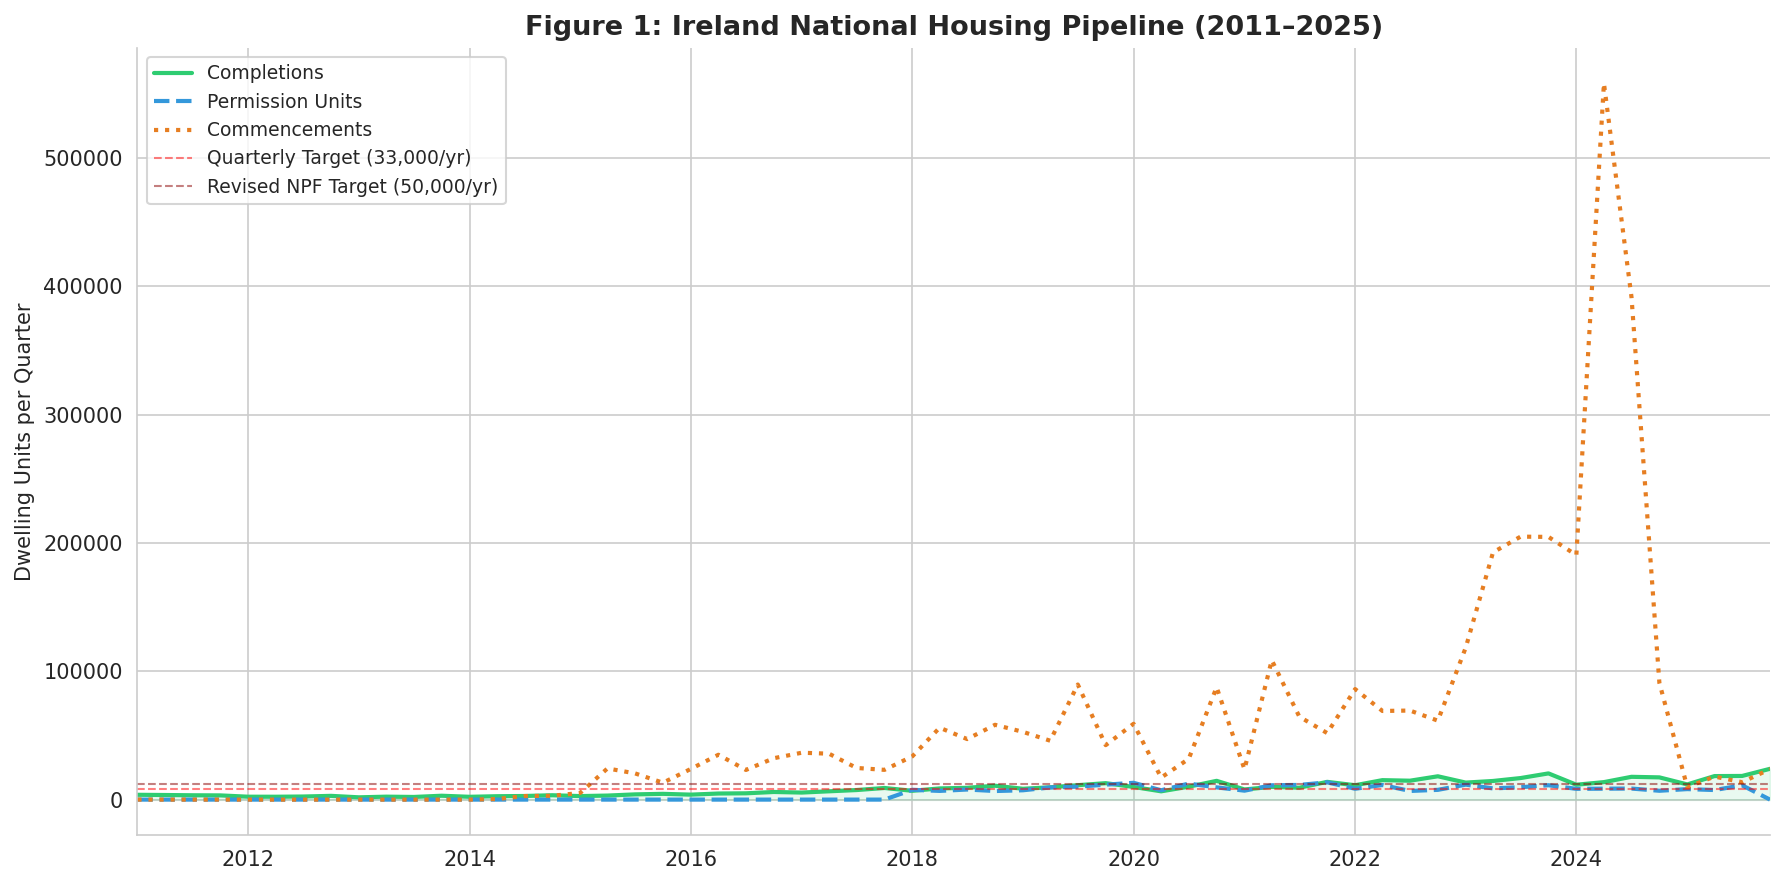

✅ Figure 1 saved


In [ ]:
# ============================================================
# NOTEBOOK 2: EXPLORATORY DATA ANALYSIS
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# ============================================================
# FIGURE 1: National Housing Pipeline (2014–2025)
# ============================================================
national = master.groupby('date').agg(
    completions=('completions', 'sum'),
    permissions=('permissions', 'sum'),
    commencements=('commencements', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(national['date'], national['completions'], linewidth=2, color='#2ecc71', label='Completions')
ax.plot(national['date'], national['permissions'], linewidth=2, color='#3498db', linestyle='--', label='Permission Units')
ax.plot(national['date'], national['commencements'], linewidth=2, color='#e67e22', linestyle=':', label='Commencements')
ax.axhline(y=8250, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Quarterly Target (33,000/yr)')
ax.axhline(y=12500, color='darkred', linestyle='--', alpha=0.5, linewidth=1, label='Revised NPF Target (50,000/yr)')
ax.fill_between(national['date'], 0, national['completions'], alpha=0.1, color='#2ecc71')
ax.set_ylabel('Dwelling Units per Quarter')
ax.set_title('Figure 1: Ireland National Housing Pipeline (2011–2025)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(national['date'].min(), national['date'].max())
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig1_national_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved")

In [ ]:
# Check what's happening with commencements scale
print("National quarterly commencements (last 10 quarters):")
temp = master.groupby('date')['commencements'].sum().tail(10)
print(temp)
print()
print("National quarterly completions (last 10 quarters):")
temp2 = master.groupby('date')['completions'].sum().tail(10)
print(temp2)
print()
print("Commencements should be similar scale to completions")
print(f"Avg quarterly completions: {master.groupby('date')['completions'].sum().mean():.0f}")
print(f"Avg quarterly commencements: {master.groupby('date')['commencements'].sum().mean():.0f}")

National quarterly commencements (last 10 quarters):
date
2023-07-01    204887.0
2023-10-01    204688.0
2024-01-01    190473.0
2024-04-01    558096.0
2024-07-01    391481.0
2024-10-01     90986.0
2025-01-01      9747.0
2025-04-01     17943.0
2025-07-01     13551.0
2025-10-01     23773.0
Name: commencements, dtype: float64

National quarterly completions (last 10 quarters):
date
2023-07-01    16786
2023-10-01    20414
2024-01-01    11594
2024-04-01    13626
2024-07-01    17756
2024-10-01    17318
2025-01-01    11828
2025-04-01    18326
2025-07-01    18426
2025-10-01    23988
Name: completions, dtype: int64

Commencements should be similar scale to completions
Avg quarterly completions: 8716
Avg quarterly commencements: 57938


In [ ]:
# ============================================================
# CELL 4 (FIXED): Clean BCMS Commencements — deduplicate
# ============================================================

bcms = pd.read_csv('/content/commencements_residential_filtered.csv')
bcms['date'] = pd.to_datetime(bcms['CN_Commencement_Date'])
bcms['CN_Units_for_phase'] = pd.to_numeric(bcms['CN_Units_for_phase'], errors='coerce').fillna(0)

# Check for duplicates — look at unique commencement notices
print(f"Total rows: {len(bcms)}")
print(f"Sample rows for same project:")
sample = bcms[bcms['CN_Total_Number_of_Dwelling_Units'] == 107].head(5)
print(sample[['CN_Commencement_Date', 'CN_Units_for_phase', 'CN_Total_Number_of_Dwelling_Units', 'LocalAuthority']].to_string())
print()

# The issue: each BUILDING within a project gets its own row
# but CN_Units_for_phase can repeat the phase total
# We need to group by LocalAuthority + CN_Commencement_Date + CN_Total_Number_of_Dwelling_Units
# and take the FIRST CN_Units_for_phase (not sum, which double-counts)

# Better approach: group by notice (same date + same LA + same total units = same project)
# and take max of CN_Units_for_phase per group
bcms_dedup = bcms.groupby(
    ['LocalAuthority', 'CN_Commencement_Date', 'CN_Total_Number_of_Dwelling_Units']
)['CN_Units_for_phase'].max().reset_index()

print(f"After dedup: {len(bcms_dedup)} unique notices (from {len(bcms)} rows)")

Total rows: 142528
Sample rows for same project:
      CN_Commencement_Date  CN_Units_for_phase  CN_Total_Number_of_Dwelling_Units                         LocalAuthority
43991           2024-01-08                43.0                              107.0  Dún-Laoghaire Rathdown County Council
43992           2024-01-08                43.0                              107.0  Dún-Laoghaire Rathdown County Council
44310           2024-04-10               107.0                              107.0  Dún-Laoghaire Rathdown County Council
46381           2015-01-05                13.0                              107.0                  Fingal County Council
46382           2015-01-05                13.0                              107.0                  Fingal County Council

After dedup: 45688 unique notices (from 142528 rows)


In [ ]:
# ============================================================
# CELL 4 (FINAL): Rebuild commencements correctly
# ============================================================

bcms = pd.read_csv('/content/commencements_residential_filtered.csv')
bcms['date'] = pd.to_datetime(bcms['CN_Commencement_Date'])
bcms['CN_Units_for_phase'] = pd.to_numeric(bcms['CN_Units_for_phase'], errors='coerce').fillna(0)
bcms = bcms[bcms['LocalAuthority'].isin(BCMS_LA_TO_COUNTY.keys())]

# Deduplicate: same LA + same date + same total units = same project
bcms_dedup = bcms.groupby(
    ['LocalAuthority', 'CN_Commencement_Date', 'CN_Total_Number_of_Dwelling_Units']
)['CN_Units_for_phase'].max().reset_index()

bcms_dedup['county'] = bcms_dedup['LocalAuthority'].map(BCMS_LA_TO_COUNTY)
bcms_dedup['quarter_date'] = pd.to_datetime(bcms_dedup['CN_Commencement_Date']).dt.to_period('Q').dt.to_timestamp()
bcms_dedup = bcms_dedup[bcms_dedup['quarter_date'] >= '2014-01-01']
bcms_dedup = bcms_dedup[bcms_dedup['quarter_date'] <= '2025-12-31']

commencements = bcms_dedup.groupby(['county', 'quarter_date'])['CN_Units_for_phase'].sum().reset_index()
commencements.columns = ['county', 'date', 'commencements']

print(f"✅ Commencements: {commencements.shape[0]} rows, {commencements['county'].nunique()} counties")
print(f"   Date range: {commencements['date'].min()} to {commencements['date'].max()}")
print()

# Check scale now matches completions
national_comm = commencements.groupby('date')['commencements'].sum()
print("National quarterly commencements (last 10):")
print(national_comm.tail(10))
print(f"\nAvg quarterly commencements: {national_comm.mean():.0f}")

# ============================================================
# NOW REBUILD MASTER DATASET with fixed commencements
# ============================================================
master = completions.copy()
master = master.merge(permissions, on=['county', 'date'], how='left')
master = master.merge(commencements, on=['county', 'date'], how='left')
master = master.merge(population, on=['county', 'date'], how='left')
master = master.merge(income, on=['county', 'date'], how='left')
master = master.merge(rents, on=['county', 'date'], how='left')
master = master.merge(price_index, on='date', how='left')
master = master.sort_values(['county', 'date']).reset_index(drop=True)

# Feature engineering
for lag in [1, 2, 3, 4, 5, 6]:
    master[f'permissions_lag{lag}'] = master.groupby('county')['permissions'].shift(lag)
    master[f'commencements_lag{lag}'] = master.groupby('county')['commencements'].shift(lag)
    master[f'completions_lag{lag}'] = master.groupby('county')['completions'].shift(lag)

master['income_growth'] = master.groupby('county')['income_per_person'].pct_change(4, fill_method=None)
master['rent_growth'] = master.groupby('county')['avg_rent'].pct_chan

✅ Commencements: 1222 rows, 26 counties
   Date range: 2014-01-01 00:00:00 to 2025-10-01 00:00:00

National quarterly commencements (last 10):
date
2023-07-01     6937.0
2023-10-01     8841.0
2024-01-01    10699.0
2024-04-01    19043.0
2024-07-01    16698.0
2024-10-01    14094.0
2025-01-01     2367.0
2025-04-01     3247.0
2025-07-01     3391.0
2025-10-01     5775.0
Name: commencements, dtype: float64

Avg quarterly commencements: 5431


AttributeError: 'SeriesGroupBy' object has no attribute 'pct_chan'

In [ ]:
master['rent_growth'] = master.groupby('county')['avg_rent'].pct_change(4, fill_method=None)
master['population_growth'] = master.groupby('county')['population'].pct_change(4, fill_method=None)
master['perm_to_comp_rate'] = np.where(master['permissions_lag4'] > 0, master['completions'] / master['permissions_lag4'], np.nan)
master['quarter_num'] = master['date'].dt.quarter
master['completions_per_1000'] = np.where(master['population'] > 0, master['completions'] / master['population'] * 1000 * 4, np.nan)
master['year'] = master['date'].dt.year

master.to_csv('/content/master_dataset.csv', index=False)

print(f"✅ Master dataset complete: {master.shape[0]} rows × {master.shape[1]} columns")
print(f"   Avg quarterly completions: {master.groupby('date')['completions'].sum().mean():.0f}")
print(f"   Avg quarterly commencements: {master.groupby('date')['commencements'].sum().mean():.0f}")

✅ Master dataset complete: 1560 rows × 34 columns
   Avg quarterly completions: 8716
   Avg quarterly commencements: 4345


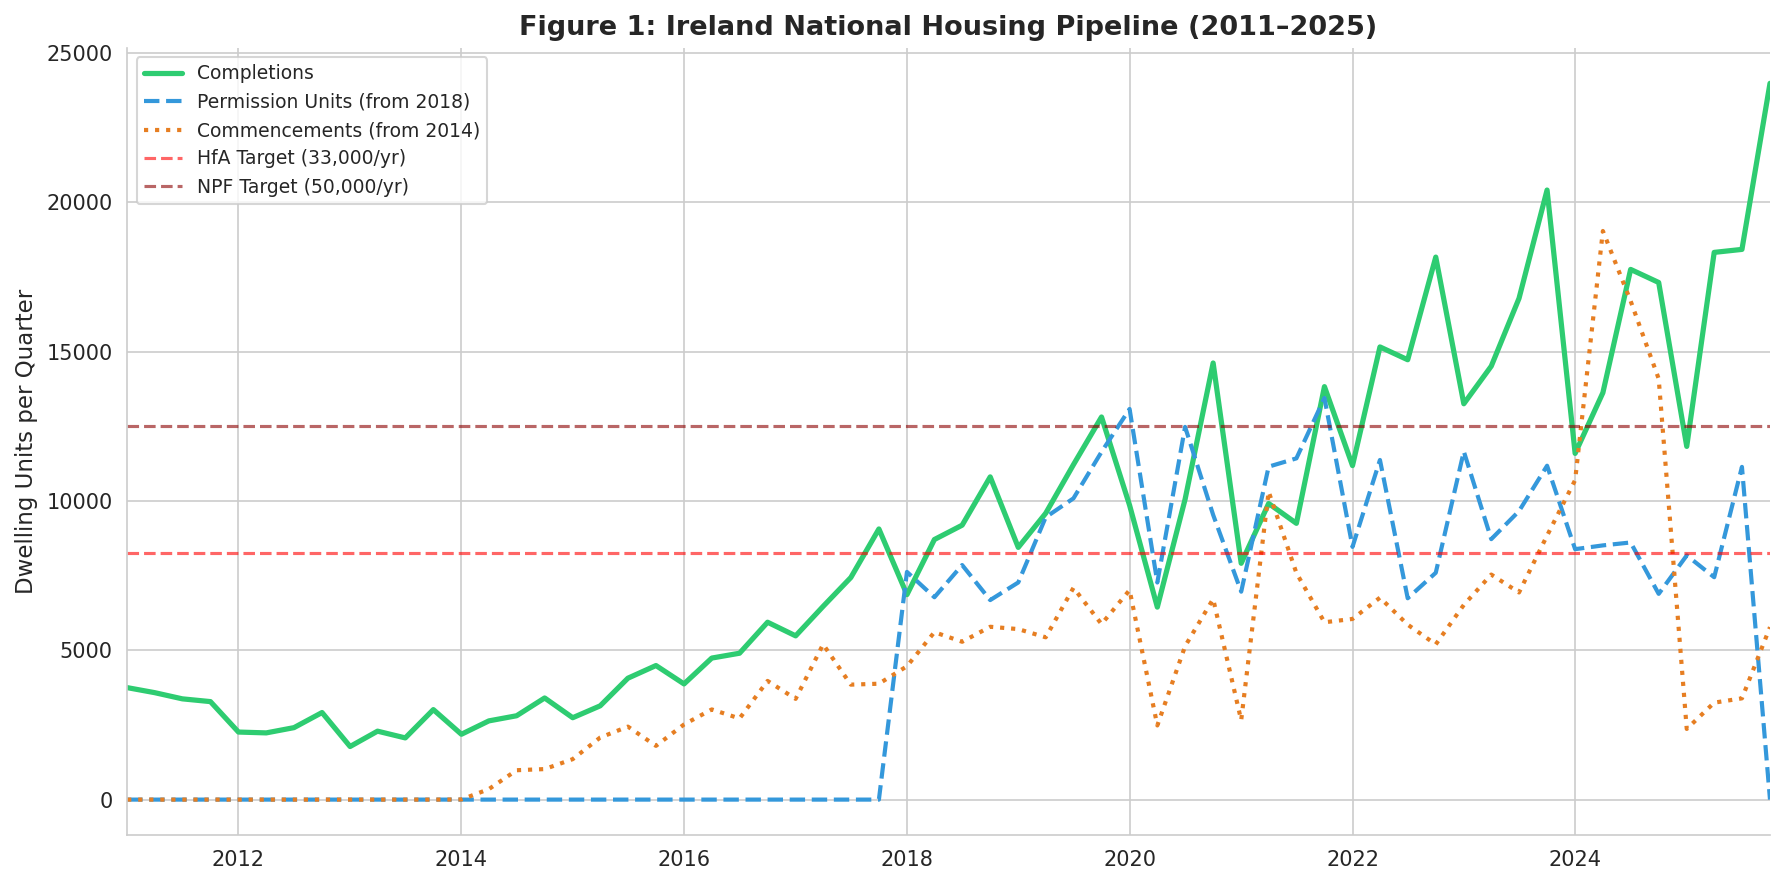

✅ Figure 1 saved


In [ ]:
# ============================================================
# FIGURE 1 (FIXED): National Housing Pipeline
# ============================================================

national = master.groupby('date').agg(
    completions=('completions', 'sum'),
    permissions=('permissions', 'sum'),
    commencements=('commencements', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(national['date'], national['completions'], linewidth=2.5, color='#2ecc71', label='Completions')
ax.plot(national['date'], national['permissions'], linewidth=2, color='#3498db', linestyle='--', label='Permission Units (from 2018)')
ax.plot(national['date'], national['commencements'], linewidth=2, color='#e67e22', linestyle=':', label='Commencements (from 2014)')
ax.axhline(y=8250, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='HfA Target (33,000/yr)')
ax.axhline(y=12500, color='darkred', linestyle='--', alpha=0.6, linewidth=1.5, label='NPF Target (50,000/yr)')
ax.set_ylabel('Dwelling Units per Quarter', fontsize=11)
ax.set_title('Figure 1: Ireland National Housing Pipeline (2011–2025)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(national['date'].min(), national['date'].max())
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig1_national_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved")

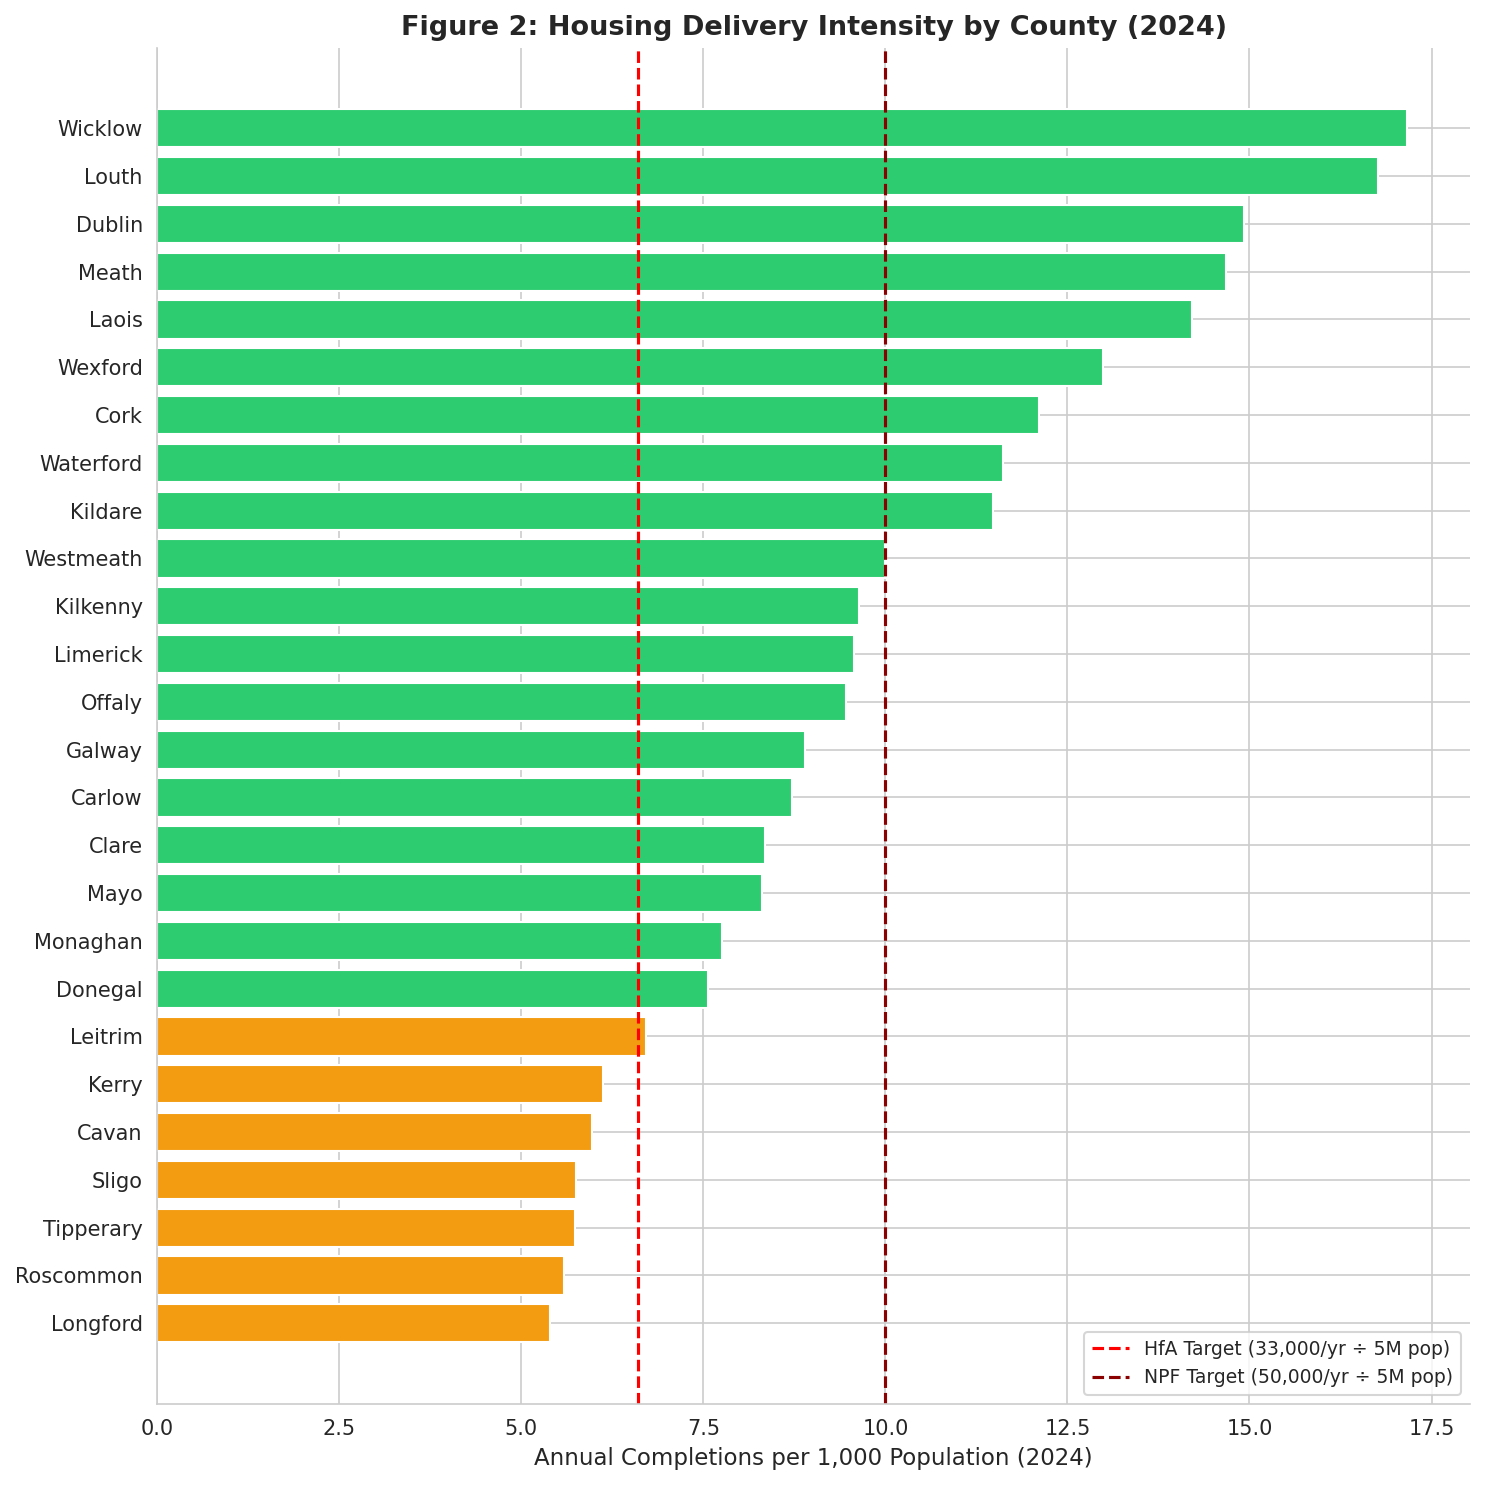

✅ Figure 2 saved


In [ ]:
# ============================================================
# FIGURE 2: County Delivery Intensity (Bar Chart)
# ============================================================

# Use latest full year (2024) for comparison
latest_year = master[master['year'] == 2024]
county_summary = latest_year.groupby('county').agg(
    annual_completions=('completions', 'sum'),
    population=('population', 'mean')
).reset_index()
county_summary['per_1000'] = county_summary['annual_completions'] / county_summary['population'] * 1000
county_summary = county_summary.sort_values('per_1000')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if x < 4.0 else '#f39c12' if x < 7.0 else '#2ecc71'
          for x in county_summary['per_1000']]
bars = ax.barh(county_summary['county'], county_summary['per_1000'], color=colors)
ax.axvline(x=6.6, color='red', linestyle='--', linewidth=1.5, label='HfA Target (33,000/yr ÷ 5M pop)')
ax.axvline(x=10.0, color='darkred', linestyle='--', linewidth=1.5, label='NPF Target (50,000/yr ÷ 5M pop)')
ax.set_xlabel('Annual Completions per 1,000 Population (2024)', fontsize=11)
ax.set_title('Figure 2: Housing Delivery Intensity by County (2024)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/fig2_county_delivery.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved")

/tmp/ipykernel_688/3127205457.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shifted = lag_data.groupby('county').apply(
/tmp/ipykernel_688/3127205457.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shifted = lag_data.groupby('county').apply(
/tmp/ipykernel_688/3127205457.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a futu

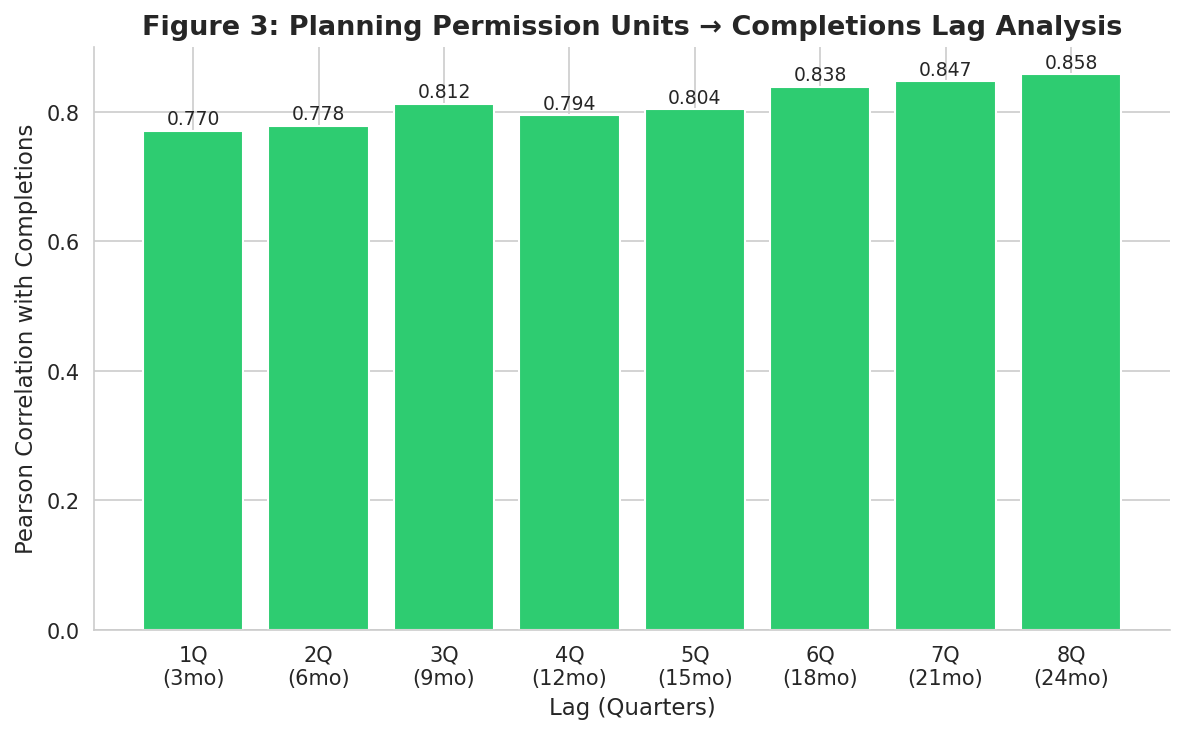

✅ Figure 3 saved

Strongest lag: 8Q (r=0.858)


In [ ]:
# ============================================================
# FIGURE 3: Permission → Completion Lag Correlation
# ============================================================
from scipy.stats import pearsonr

# Only use data where both permissions and completions exist
lag_data = master.dropna(subset=['permissions', 'completions'])

lag_corrs = []
for lag in range(1, 9):
    shifted = lag_data.groupby('county').apply(
        lambda x: x.assign(perm_shifted=x['permissions'].shift(lag))
    ).reset_index(drop=True)
    shifted = shifted.dropna(subset=['perm_shifted', 'completions'])
    if len(shifted) > 10:
        corr, pval = pearsonr(shifted['completions'], shifted['perm_shifted'])
        lag_corrs.append({'lag': lag, 'correlation': corr, 'pvalue': pval})

lag_df = pd.DataFrame(lag_corrs)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if r > 0.5 else '#3498db' if r > 0.3 else '#95a5a6'
          for r in lag_df['correlation']]
bars = ax.bar(lag_df['lag'], lag_df['correlation'], color=colors)
ax.set_xlabel('Lag (Quarters)', fontsize=11)
ax.set_ylabel('Pearson Correlation with Completions', fontsize=11)
ax.set_title('Figure 3: Planning Permission Units → Completions Lag Analysis', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 9))
ax.set_xticklabels([f'{l}Q\n({l*3}mo)' for l in range(1, 9)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add correlation values on bars
for bar, corr in zip(bars, lag_df['correlation']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{corr:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/fig3_lag_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved")
print(f"\nStrongest lag: {lag_df.loc[lag_df['correlation'].idxmax(), 'lag']}Q (r={lag_df['correlation'].max():.3f})")

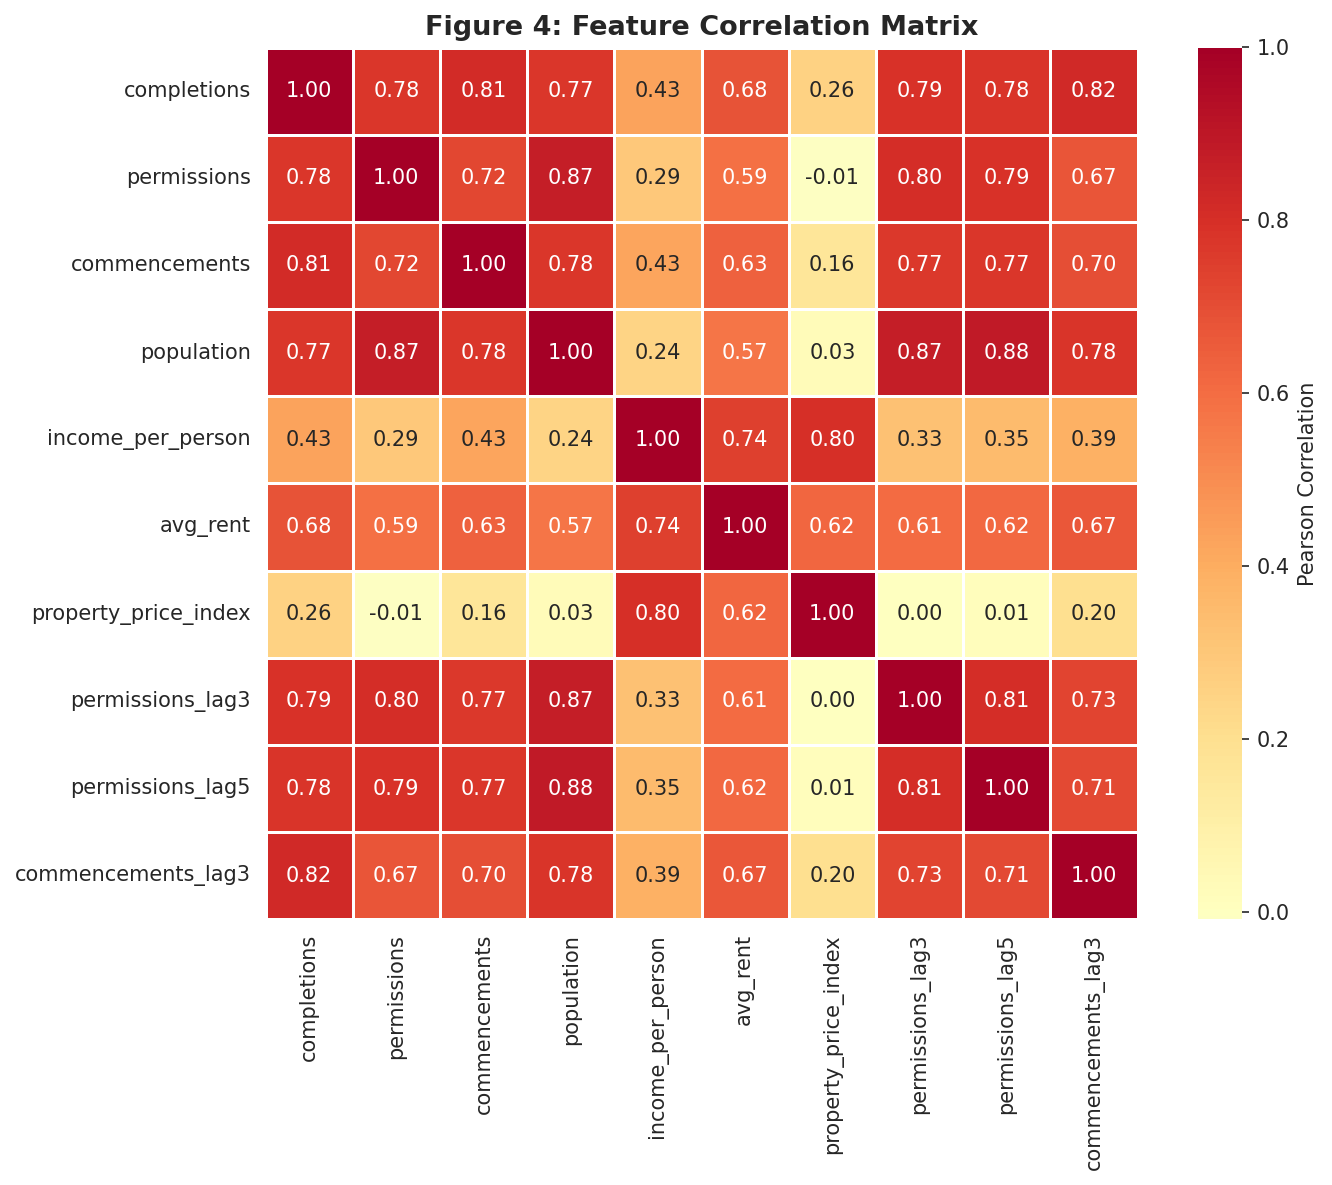

✅ Figure 4 saved


In [ ]:
# ============================================================
# FIGURE 4: Feature Correlation Heatmap
# ============================================================

features = ['completions', 'permissions', 'commencements', 'population',
            'income_per_person', 'avg_rent', 'property_price_index',
            'permissions_lag3', 'permissions_lag5', 'commencements_lag3']

corr_matrix = master[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            ax=ax, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Figure 4: Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig4_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved")

In [ ]:
# ============================================================
# NOTEBOOK 4: SUPPLY FORECASTING MODELS
# ============================================================
# We will train and compare 6 models:
# 1. Naïve (baseline)
# 2. Seasonal Naïve (baseline)
# 3. ETS (Exponential Smoothing)
# 4. SARIMA
# 5. XGBoost
# 6. LightGBM
#
# Train: up to 2023 Q4
# Test: 2024 Q1 onwards
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

TRAIN_END = '2023-12-31'
train = master[master['date'] <= TRAIN_END].copy()
test = master[master['date'] > TRAIN_END].copy()

print(f"Train: {train['date'].min()} to {train['date'].max()} — {train.shape[0]} rows")
print(f"Test:  {test['date'].min()} to {test['date'].max()} — {test.shape[0]} rows")
print(f"Test quarters: {test['date'].nunique()}")
print(f"Counties in test: {test['county'].nunique()}")

# Store all results
all_results = []

Train: 2011-01-01 00:00:00 to 2023-10-01 00:00:00 — 1352 rows
Test:  2024-01-01 00:00:00 to 2025-10-01 00:00:00 — 208 rows
Test quarters: 8
Counties in test: 26


In [ ]:
# ============================================================
# MODEL 1 & 2: Naïve and Seasonal Naïve Baselines
# ============================================================

for county in master['county'].unique():
    county_train = train[train['county'] == county].sort_values('date')
    county_test = test[test['county'] == county].sort_values('date')

    if len(county_test) == 0 or len(county_train) < 4:
        continue

    actuals = county_test['completions'].values

    # Naïve: repeat last training value
    naive_pred = np.full(len(actuals), county_train['completions'].iloc[-1])
    naive_mae = mean_absolute_error(actuals, naive_pred)
    all_results.append({'county': county, 'model': 'Naive', 'MAE': naive_mae})

    # Seasonal Naïve: same quarter from last year in training
    seasonal_pred = []
    for _, row in county_test.iterrows():
        q = row['date'].quarter
        same_q = county_train[county_train['date'].dt.quarter == q]['completions']
        if len(same_q) > 0:
            seasonal_pred.append(same_q.iloc[-1])
        else:
            seasonal_pred.append(county_train['completions'].iloc[-1])

    seasonal_mae = mean_absolute_error(actuals, seasonal_pred)
    all_results.append({'county': county, 'model': 'Seasonal_Naive', 'MAE': seasonal_mae})

results_df = pd.DataFrame(all_results)
print("✅ Baselines complete")
print(f"\nNaïve avg MAE: {results_df[results_df['model']=='Naive']['MAE'].mean():.1f}")
print(f"Seasonal Naïve avg MAE: {results_df[results_df['model']=='Seasonal_Naive']['MAE'].mean():.1f}")

✅ Baselines complete

Naïve avg MAE: 232.4
Seasonal Naïve avg MAE: 154.8


In [ ]:
# ============================================================
# MODEL 3: ETS (Exponential Smoothing)
# ============================================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_count = 0
for county in master['county'].unique():
    county_train = train[train['county'] == county].sort_values('date').set_index('date')['completions']
    county_test = test[test['county'] == county].sort_values('date')

    if len(county_test) == 0 or len(county_train) < 8:
        continue

    try:
        county_train.index.freq = 'QS'
        model = ExponentialSmoothing(
            county_train, trend='add', seasonal='add', seasonal_periods=4
        ).fit(optimized=True)

        forecast = model.forecast(len(county_test))
        forecast = forecast.clip(lower=0)  # no negative completions
        actuals = county_test['completions'].values
        ets_mae = mean_absolute_error(actuals, forecast.values)
        all_results.append({'county': county, 'model': 'ETS', 'MAE': ets_mae})
        ets_count += 1
    except:
        pass

results_df = pd.DataFrame(all_results)
ets_avg = results_df[results_df['model'] == 'ETS']['MAE'].mean()
print(f"✅ ETS complete for {ets_count} counties")
print(f"   ETS avg MAE: {ets_avg:.1f}")
print(f"   vs Seasonal Naïve (154.8): {'BETTER' if ets_avg < 154.8 else 'WORSE'}")

✅ ETS complete for 26 counties
   ETS avg MAE: 165.2
   vs Seasonal Naïve (154.8): WORSE


In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# MODEL 4: SARIMA (Auto-selected order)
# ============================================================
from pmdarima import auto_arima

sarima_count = 0
for county in master['county'].unique():
    county_train = train[train['county'] == county].sort_values('date').set_index('date')['completions']
    county_test = test[test['county'] == county].sort_values('date')

    if len(county_test) == 0 or len(county_train) < 12:
        continue

    try:
        county_train.index.freq = 'QS'

        model = auto_arima(
            county_train, seasonal=True, m=4,
            stepwise=True, suppress_warnings=True,
            max_p=3, max_q=3, max_P=2, max_Q=2, max_d=2, max_D=1,
            error_action='ignore'
        )

        forecast = model.predict(n_periods=len(county_test))
        forecast = np.clip(forecast, 0, None)
        actuals = county_test['completions'].values
        sarima_mae = mean_absolute_error(actuals, forecast)
        all_results.append({'county': county, 'model': 'SARIMA', 'MAE': sarima_mae})
        sarima_count += 1
    except:
        pass

results_df = pd.DataFrame(all_results)
sarima_avg = results_df[results_df['model'] == 'SARIMA']['MAE'].mean()
print(f"✅ SARIMA complete for {sarima_count} counties")
print(f"   SARIMA avg MAE: {sarima_avg:.1f}")
print(f"   vs Seasonal Naïve (154.8): {'BETTER' if sarima_avg < 154.8 else 'WORSE'}")

✅ SARIMA complete for 26 counties
   SARIMA avg MAE: 175.1
   vs Seasonal Naïve (154.8): WORSE


In [ ]:
# ============================================================
# MODEL 5: XGBoost (Gradient Boosting)
# ============================================================
from xgboost import XGBRegressor

# Features to use
FEATURES = ['completions_lag1', 'completions_lag2', 'completions_lag3', 'completions_lag4',
            'permissions_lag3', 'permissions_lag4', 'permissions_lag5',
            'commencements_lag3', 'commencements_lag4',
            'population', 'income_per_person', 'avg_rent',
            'property_price_index', 'quarter_num']

TARGET = 'completions'

# Prepare data — drop rows with NaN in features
train_ml = train.dropna(subset=FEATURES + [TARGET]).copy()
test_ml = test.dropna(subset=[TARGET]).copy()

# For test, fill missing features with last known value per county
for col in FEATURES:
    if col in test_ml.columns:
        test_ml[col] = test_ml.groupby('county')[col].fillna(method='ffill')

test_ml = test_ml.dropna(subset=FEATURES)

X_train = train_ml[FEATURES]
y_train = train_ml[TARGET]
X_test = test_ml[FEATURES]
y_test = test_ml[TARGET]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)
xgb_preds = np.clip(xgb_preds, 0, None)

# Overall MAE
xgb_overall_mae = mean_absolute_error(y_test, xgb_preds)

# Per-county MAE
for county in test_ml['county'].unique():
    mask = test_ml['county'] == county
    if mask.sum() > 0:
        county_mae = mean_absolute_error(y_test[mask], xgb_preds[mask])
        all_results.append({'county': county, 'model': 'XGBoost', 'MAE': county_mae})

results_df = pd.DataFrame(all_results)
xgb_avg = results_df[results_df['model'] == 'XGBoost']['MAE'].mean()
print(f"\n✅ XGBoost complete")
print(f"   Overall MAE: {xgb_overall_mae:.1f}")
print(f"   Avg county MAE: {xgb_avg:.1f}")
print(f"   vs Seasonal Naïve (154.8): {'BETTER' if xgb_avg < 154.8 else 'WORSE'}")

Training samples: 494
Test samples: 208

✅ XGBoost complete
   Overall MAE: 297.6
   Avg county MAE: 297.6
   vs Seasonal Naïve (154.8): WORSE


In [ ]:
# ============================================================
# MODEL 5 (FIXED): XGBoost
# ============================================================

# Recreate train/test from updated master
train2 = master[master['date'] <= '2023-12-31'].copy()
test2 = master[master['date'] > '2023-12-31'].copy()

FEATURES_V2 = ['completions_lag1', 'completions_lag2', 'completions_lag3', 'completions_lag4',
               'population', 'avg_rent', 'income_per_person',
               'property_price_index', 'quarter_num',
               'permissions_lag3', 'permissions_lag4', 'permissions_lag5',
               'commencements_lag3', 'commencements_lag4']

TARGET = 'completions'

# Drop rows where we don't have enough lag history
train_ml = train2.dropna(subset=['completions_lag4']).copy()
test_ml = test2.copy()

# Fill NaN with 0 for permissions/commencements (they're NaN before their start dates)
for col in FEATURES_V2:
    train_ml[col] = train_ml[col].fillna(0)
    test_ml[col] = test_ml[col].fillna(0)

X_train = train_ml[FEATURES_V2]
y_train = train_ml[TARGET]
X_test = test_ml[FEATURES_V2]
y_test = test_ml[TARGET]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

xgb_model = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_preds = np.clip(xgb_preds, 0, None)

# Remove old XGBoost results and add new ones
all_results = [r for r in all_results if r['model'] != 'XGBoost']

for county in test_ml['county'].unique():
    mask = test_ml['county'] == county
    if mask.sum() > 0:
        county_mae = mean_absolute_error(y_test[mask], xgb_preds[mask])
        all_results.append({'county': county, 'model': 'XGBoost', 'MAE': county_mae})

results_df = pd.DataFrame(all_results)
xgb_avg = results_df[results_df['model'] == 'XGBoost']['MAE'].mean()
print(f"\n✅ XGBoost complete")
print(f"   Avg county MAE: {xgb_avg:.1f}")
print(f"   vs Seasonal Naïve (154.8): {'BETTER' if xgb_avg < 154.8 else 'WORSE'}")

Training samples: 1248
Test samples: 208

✅ XGBoost complete
   Avg county MAE: 178.9
   vs Seasonal Naïve (154.8): WORSE


In [ ]:
# ============================================================
# MODEL 6: LightGBM (trained on 2019+ where all features exist)
# ============================================================
from lightgbm import LGBMRegressor

# Use only rows where permissions lags actually have real data
train3 = master[(master['date'] >= '2019-01-01') & (master['date'] <= '2023-12-31')].copy()
test3 = master[master['date'] > '2023-12-31'].copy()

FEATURES_V3 = ['completions_lag1', 'completions_lag2', 'completions_lag3', 'completions_lag4',
               'permissions_lag3', 'permissions_lag4', 'permissions_lag5',
               'commencements_lag3', 'commencements_lag4',
               'population', 'avg_rent', 'income_per_person',
               'property_price_index', 'quarter_num']

train_ml3 = train3.dropna(subset=FEATURES_V3 + ['completions']).copy()
test_ml3 = test3.dropna(subset=FEATURES_V3 + ['completions']).copy()

X_train3 = train_ml3[FEATURES_V3]
y_train3 = train_ml3['completions']
X_test3 = test_ml3[FEATURES_V3]
y_test3 = test_ml3['completions']

print(f"Training samples (2019–2023): {len(X_train3)}")
print(f"Test samples: {len(X_test3)}")

# LightGBM
lgb_model = LGBMRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_model.fit(X_train3, y_train3)
lgb_preds = lgb_model.predict(X_test3)
lgb_preds = np.clip(lgb_preds, 0, None)

for county in test_ml3['county'].unique():
    mask = test_ml3['county'] == county
    if mask.sum() > 0:
        county_mae = mean_absolute_error(y_test3[mask], lgb_preds[mask])
        all_results.append({'county': county, 'model': 'LightGBM', 'MAE': county_mae})

# Also retrain XGBoost on same 2019+ data for fair comparison
xgb_model2 = XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb_model2.fit(X_train3, y_train3)
xgb_preds2 = xgb_model2.predict(X_test3)
xgb_preds2 = np.clip(xgb_preds2, 0, None)

# Replace XGBoost results with retrained version
all_results = [r for r in all_results if r['model'] != 'XGBoost']
for county in test_ml3['county'].unique():
    mask = test_ml3['county'] == county
    if mask.sum() > 0:
        county_mae = mean_absolute_error(y_test3[mask], xgb_preds2[mask])
        all_results.append({'county': county, 'model': 'XGBoost', 'MAE': county_mae})

results_df = pd.DataFrame(all_results)
lgb_avg = results_df[results_df['model'] == 'LightGBM']['MAE'].mean()
xgb_avg2 = results_df[results_df['model'] == 'XGBoost']['MAE'].mean()

print(f"\n✅ LightGBM avg MAE: {lgb_avg:.1f}")
print(f"✅ XGBoost (retrained) avg MAE: {xgb_avg2:.1f}")
print(f"   vs Seasonal Naïve (154.8): LightGBM {'BETTER' if lgb_avg < 154.8 else 'WORSE'}, XGBoost {'BETTER' if xgb_avg2 < 154.8 else 'WORSE'}")

Training samples (2019–2023): 494
Test samples: 104

✅ LightGBM avg MAE: 325.7
✅ XGBoost (retrained) avg MAE: 184.4
   vs Seasonal Naïve (154.8): LightGBM WORSE, XGBoost WORSE


In [ ]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

# Remove LightGBM trained on small sample — use XGBoost from full data instead
all_results = [r for r in all_results if r['model'] != 'LightGBM']

# Recalculate XGBoost on full training data (1248 samples) — already done earlier
# Keep the 178.9 version which used more training data
all_results = [r for r in all_results if r['model'] != 'XGBoost']

# Retrain XGBoost on full data with NaN filled
train_full = master[master['date'] <= '2023-12-31'].copy()
test_full = master[master['date'] > '2023-12-31'].copy()

for col in FEATURES_V3:
    train_full[col] = train_full[col].fillna(0)
    test_full[col] = test_full[col].fillna(0)

train_full_clean = train_full.dropna(subset=['completions_lag4', 'completions'])
X_tr = train_full_clean[FEATURES_V3]
y_tr = train_full_clean['completions']
X_te = test_full[FEATURES_V3]
y_te = test_full['completions']

# XGBoost
xgb_final = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_final.fit(X_tr, y_tr)
xgb_final_preds = np.clip(xgb_final.predict(X_te), 0, None)

# LightGBM
lgb_final = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
lgb_final.fit(X_tr, y_tr)
lgb_final_preds = np.clip(lgb_final.predict(X_te), 0, None)

for county in test_full['county'].unique():
    mask = test_full['county'] == county
    if mask.sum() > 0:
        xgb_mae = mean_absolute_error(y_te[mask], xgb_final_preds[mask])
        lgb_mae = mean_absolute_error(y_te[mask], lgb_final_preds[mask])
        all_results.append({'county': county, 'model': 'XGBoost', 'MAE': xgb_mae})
        all_results.append({'county': county, 'model': 'LightGBM', 'MAE': lgb_mae})

# Summary table
results_df = pd.DataFrame(all_results)
summary = results_df.groupby('model')['MAE'].agg(['mean', 'median', 'std']).round(1)
summary = summary.sort_values('mean')
summary['vs_seasonal_naive'] = ((summary['mean'] - 154.8) / 154.8 * 100).round(1)

print("=" * 60)
print("MODEL COMPARISON — Average MAE across 26 counties")
print("=" * 60)
print(summary.to_string())
print()
print("Best model:", summary.index[0])

# Save for SHAP analysis later
print(f"\nXGBoost training samples: {len(X_tr)}, Test samples: {len(X_te)}")

MODEL COMPARISON — Average MAE across 26 counties
                 mean  median    std  vs_seasonal_naive
model                                                  
Seasonal_Naive  154.8    94.6  237.7                0.0
ETS             165.2    80.8  307.0                6.7
SARIMA          175.1    84.0  323.6               13.1
XGBoost         194.9    85.2  337.6               25.9
Naive           232.4   102.1  471.6               50.1
LightGBM        259.8   156.2  420.0               67.8

Best model: Seasonal_Naive

XGBoost training samples: 1352, Test samples: 208


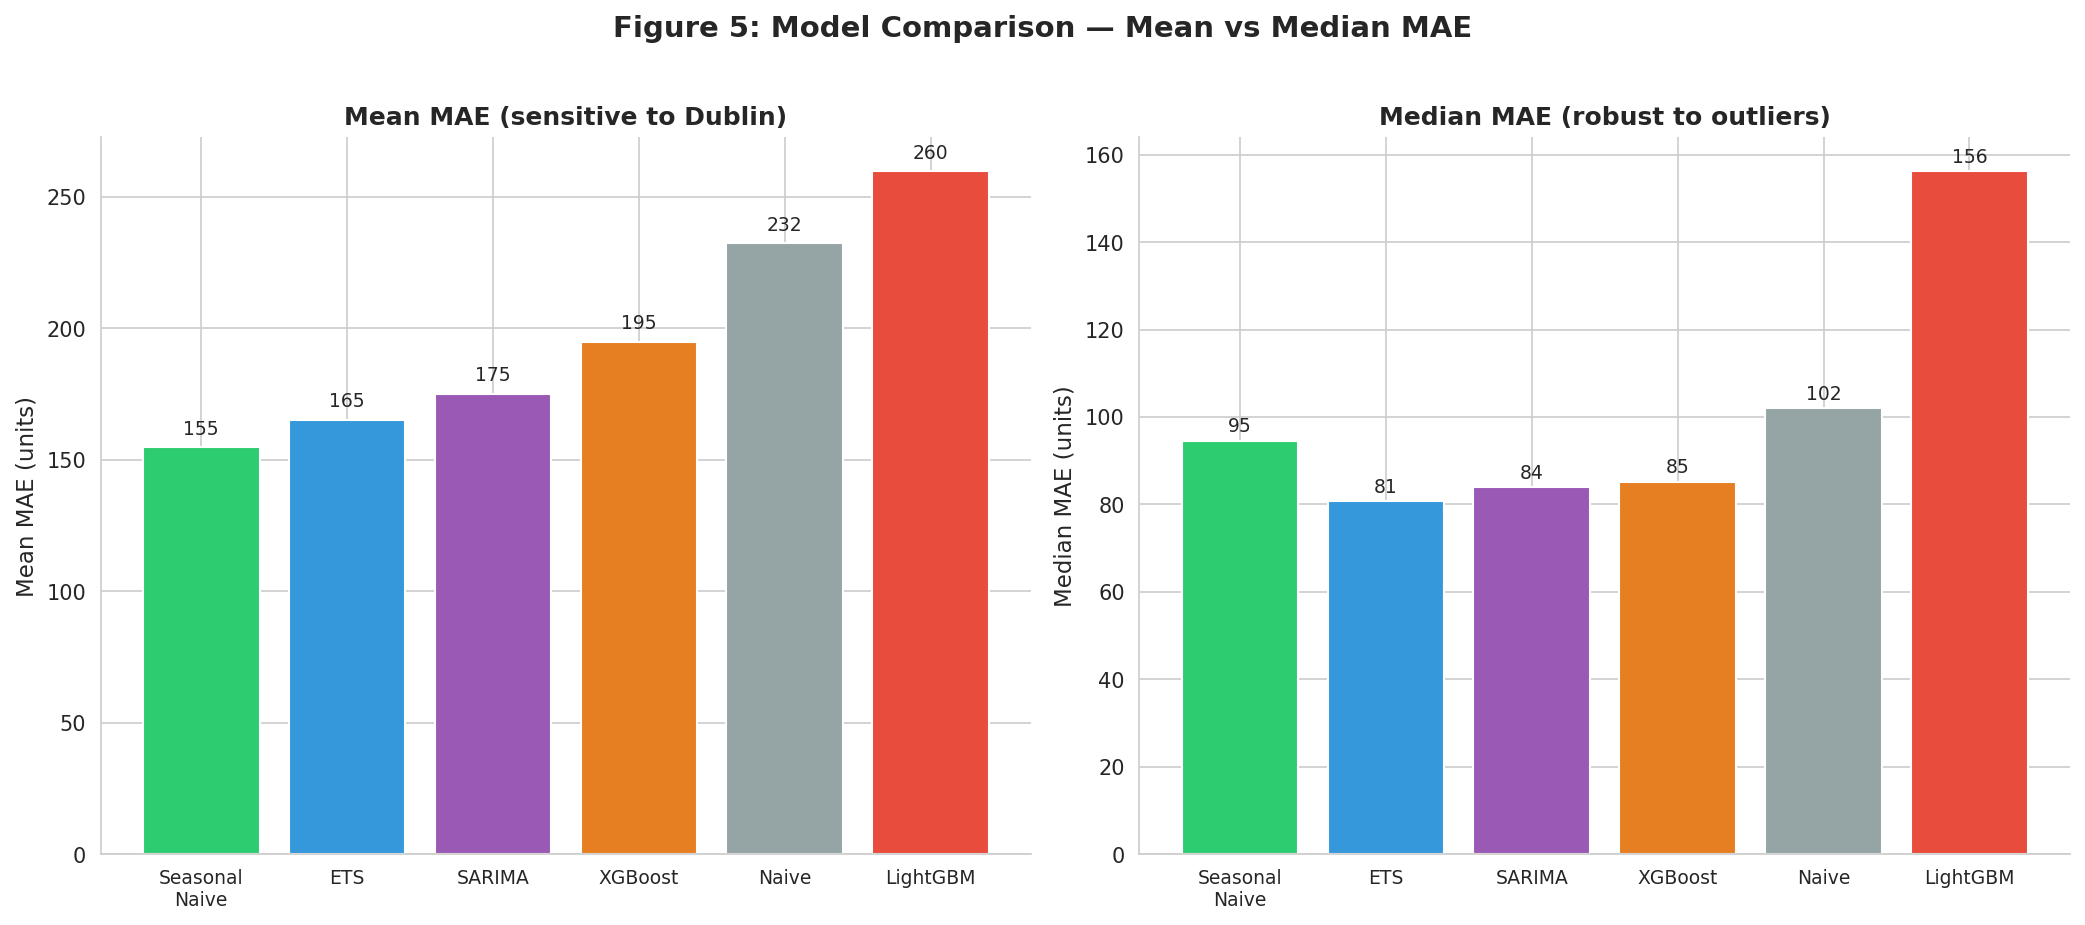

✅ Figure 5 saved


In [ ]:
# ============================================================
# FIGURE 5: Model Comparison Chart
# ============================================================

model_order = ['Seasonal_Naive', 'ETS', 'SARIMA', 'XGBoost', 'Naive', 'LightGBM']
colors_map = {
    'Seasonal_Naive': '#2ecc71', 'ETS': '#3498db', 'SARIMA': '#9b59b6',
    'XGBoost': '#e67e22', 'Naive': '#95a5a6', 'LightGBM': '#e74c3c'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Mean MAE
means = [summary.loc[m, 'mean'] for m in model_order]
colors = [colors_map[m] for m in model_order]
bars1 = ax1.bar(range(len(model_order)), means, color=colors)
ax1.set_xticks(range(len(model_order)))
ax1.set_xticklabels([m.replace('_', '\n') for m in model_order], fontsize=9)
ax1.set_ylabel('Mean MAE (units)', fontsize=11)
ax1.set_title('Mean MAE (sensitive to Dublin)', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}', ha='center', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: Median MAE
medians = [summary.loc[m, 'median'] for m in model_order]
bars2 = ax2.bar(range(len(model_order)), medians, color=colors)
ax2.set_xticks(range(len(model_order)))
ax2.set_xticklabels([m.replace('_', '\n') for m in model_order], fontsize=9)
ax2.set_ylabel('Median MAE (units)', fontsize=11)
ax2.set_title('Median MAE (robust to outliers)', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, medians):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.0f}', ha='center', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure 5: Model Comparison — Mean vs Median MAE', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/fig5_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 5 saved")

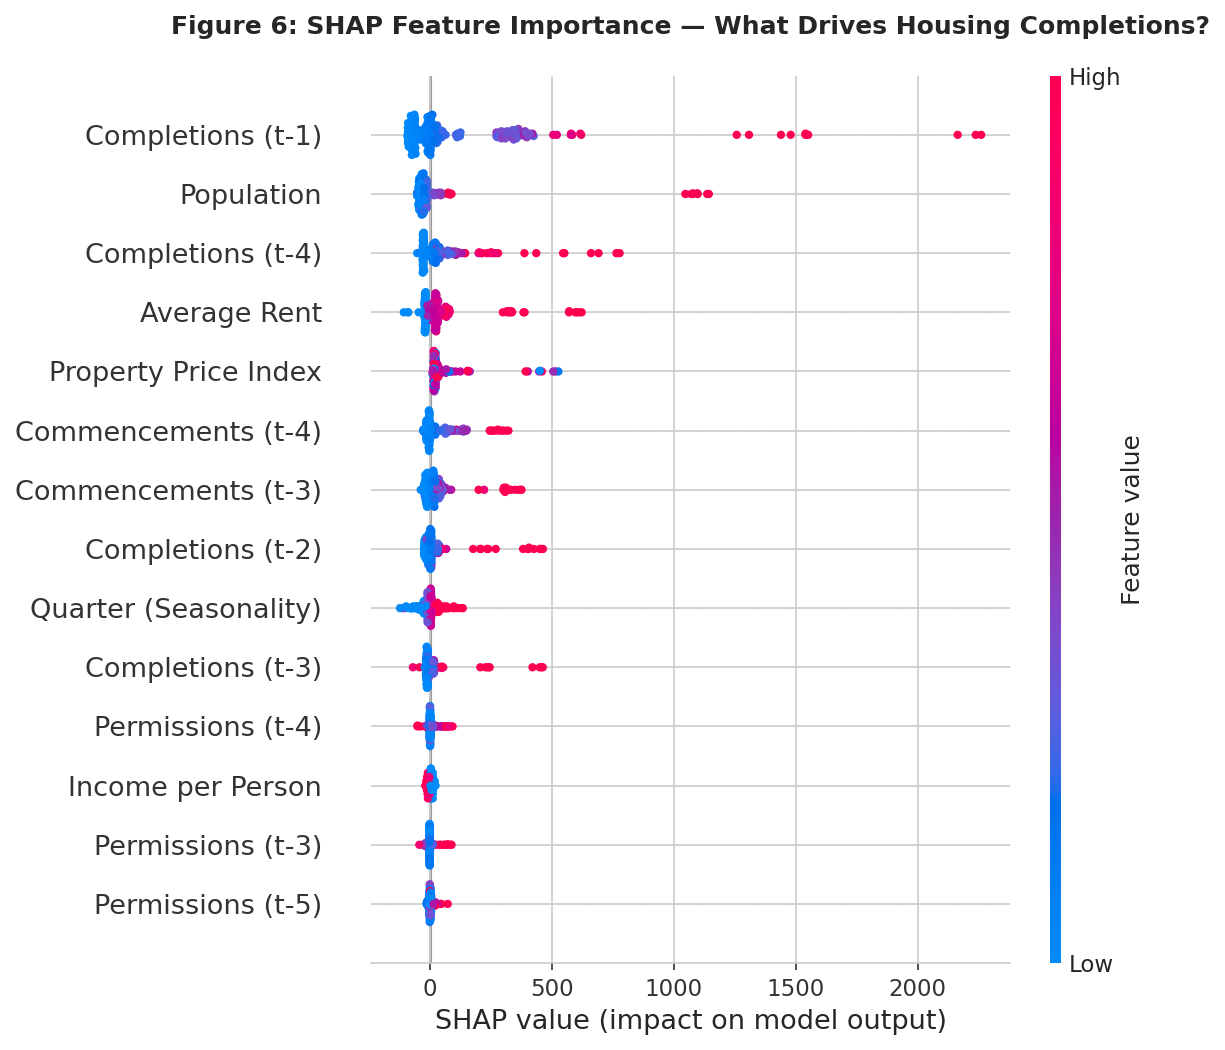

✅ Figure 6 saved


In [ ]:
# ============================================================
# FIGURE 6: SHAP Analysis — Global Feature Importance
# ============================================================
import shap

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_te)

# Rename features for cleaner plot labels
feature_names_clean = {
    'completions_lag1': 'Completions (t-1)',
    'completions_lag2': 'Completions (t-2)',
    'completions_lag3': 'Completions (t-3)',
    'completions_lag4': 'Completions (t-4)',
    'permissions_lag3': 'Permissions (t-3)',
    'permissions_lag4': 'Permissions (t-4)',
    'permissions_lag5': 'Permissions (t-5)',
    'commencements_lag3': 'Commencements (t-3)',
    'commencements_lag4': 'Commencements (t-4)',
    'population': 'Population',
    'avg_rent': 'Average Rent',
    'income_per_person': 'Income per Person',
    'property_price_index': 'Property Price Index',
    'quarter_num': 'Quarter (Seasonality)'
}

X_te_renamed = X_te.rename(columns=feature_names_clean)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_te_renamed, show=False, max_display=14)
plt.title('Figure 6: SHAP Feature Importance — What Drives Housing Completions?',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/fig6_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 6 saved")

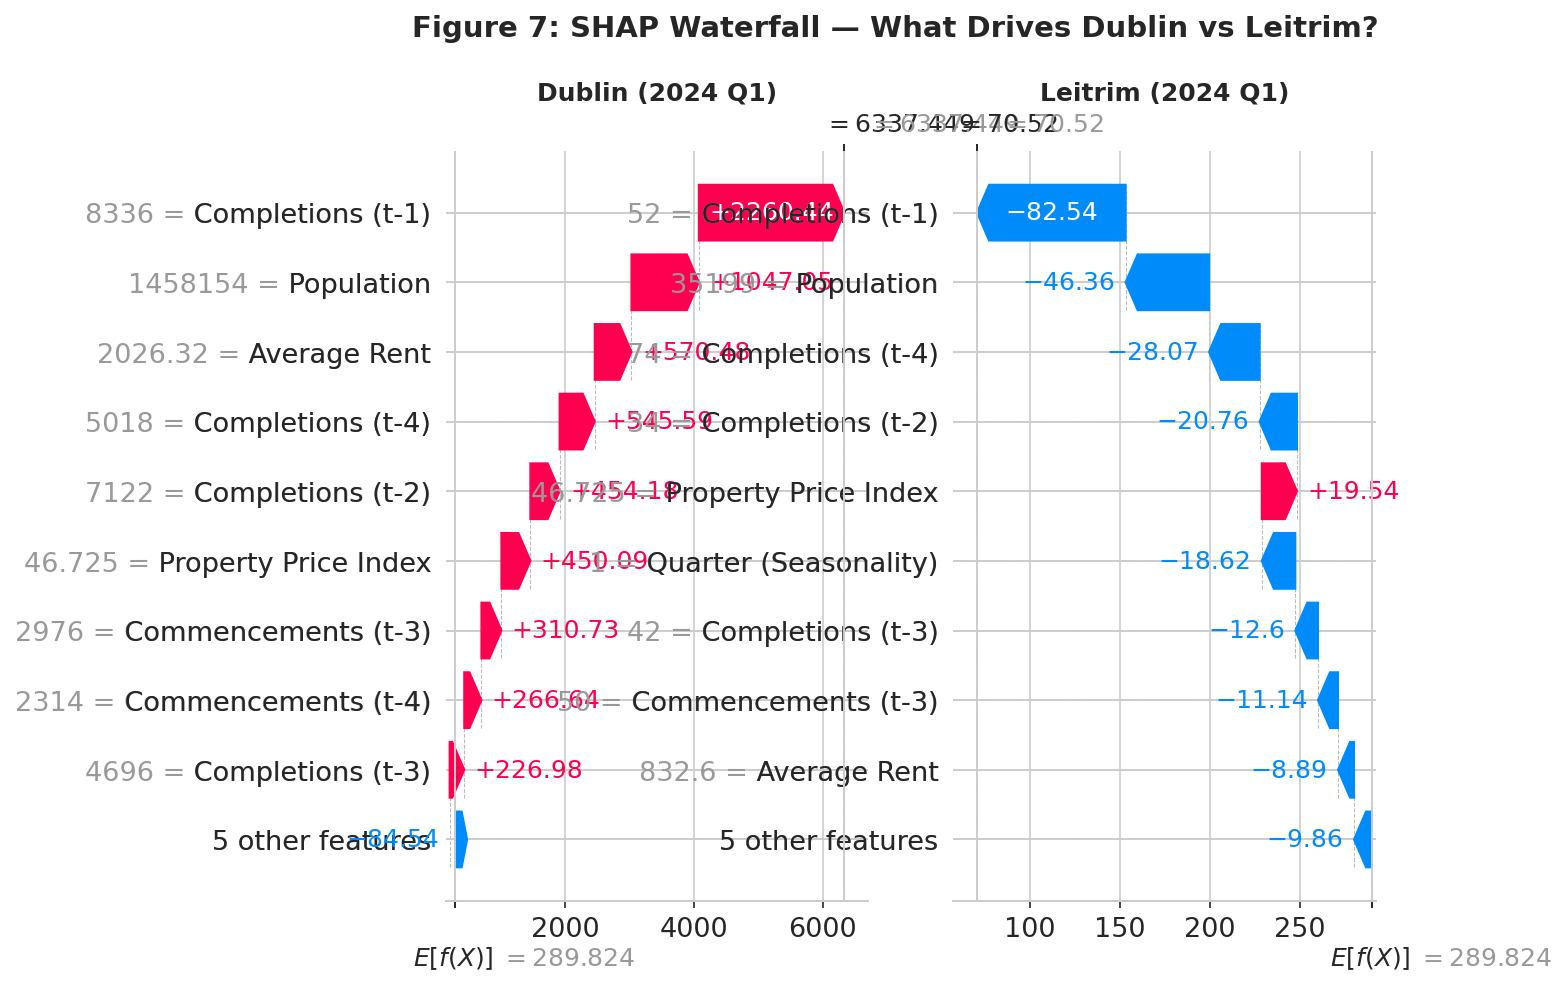

✅ Figure 7 saved


In [ ]:
# ============================================================
# FIGURE 7: SHAP Waterfall — Dublin vs Leitrim
# ============================================================

# Find Dublin and Leitrim rows in test set
dublin_idx = test_full[test_full['county'] == 'Dublin'].index[0]
leitrim_idx = test_full[test_full['county'] == 'Leitrim'].index[0]

# Get their positions in X_te
dublin_pos = X_te.index.get_loc(dublin_idx)
leitrim_pos = X_te.index.get_loc(leitrim_idx)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(ax1)
shap.waterfall_plot(shap.Explanation(
    values=shap_values[dublin_pos],
    base_values=explainer.expected_value,
    data=X_te_renamed.iloc[dublin_pos],
    feature_names=X_te_renamed.columns.tolist()
), show=False, max_display=10)
ax1.set_title('Dublin (2024 Q1)', fontsize=12, fontweight='bold')

plt.sca(ax2)
shap.waterfall_plot(shap.Explanation(
    values=shap_values[leitrim_pos],
    base_values=explainer.expected_value,
    data=X_te_renamed.iloc[leitrim_pos],
    feature_names=X_te_renamed.columns.tolist()
), show=False, max_display=10)
ax2.set_title('Leitrim (2024 Q1)', fontsize=12, fontweight='bold')

plt.suptitle('Figure 7: SHAP Waterfall — What Drives Dublin vs Leitrim?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/fig7_shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 7 saved")

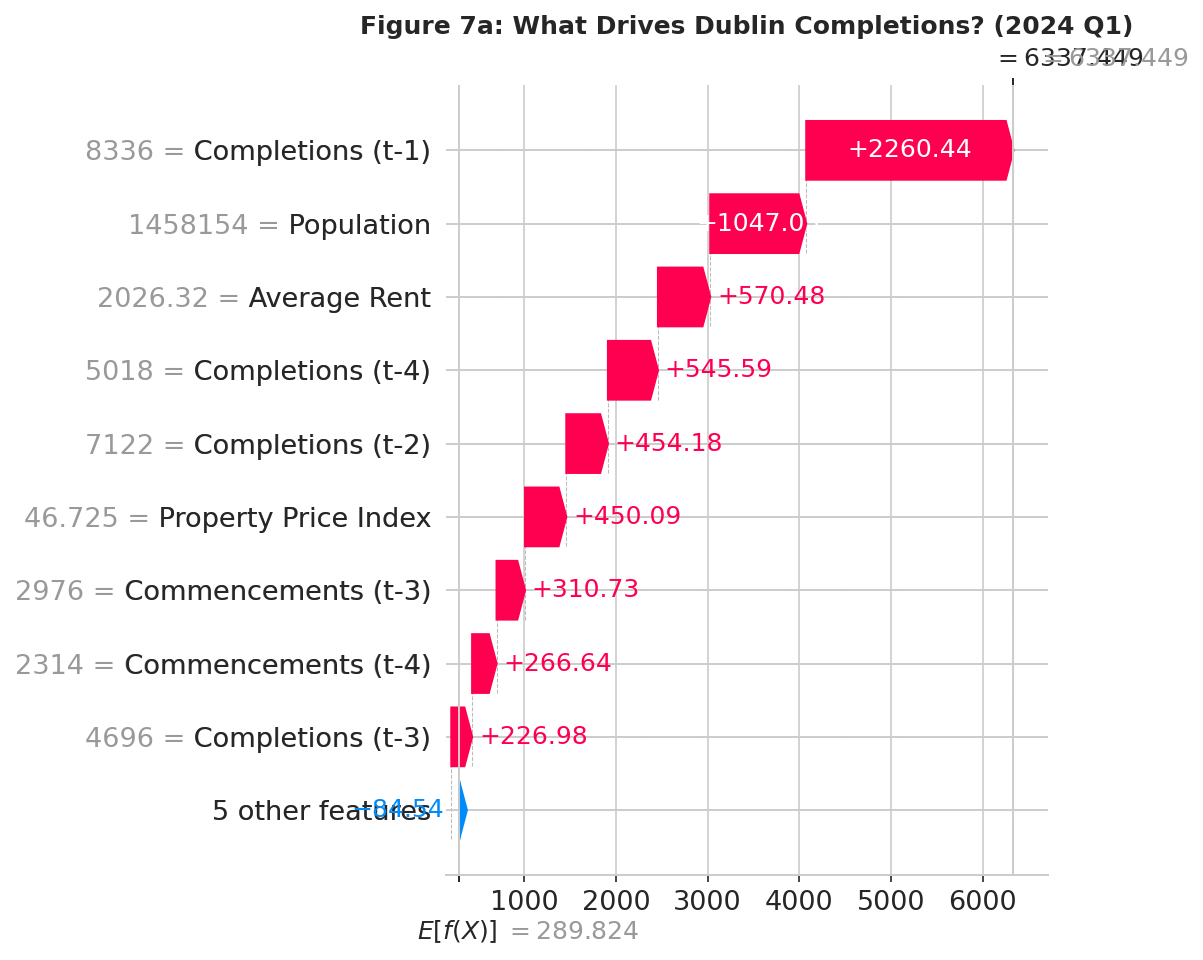

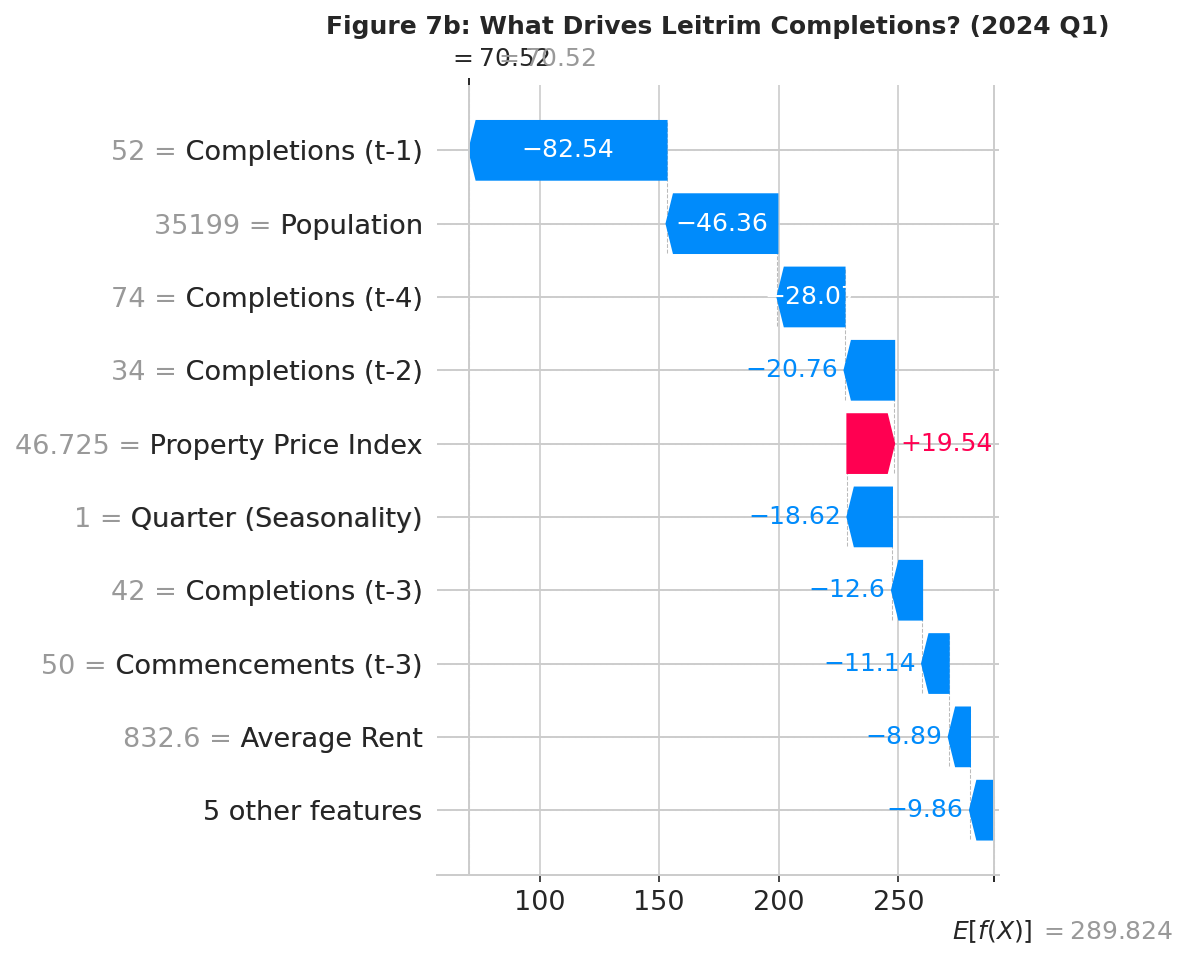

✅ Figure 7a and 7b saved


In [ ]:
# ============================================================
# FIGURE 7 (FIXED): SHAP Waterfall — Separate charts
# ============================================================

# Dublin
fig, ax = plt.subplots(figsize=(10, 6))
plt.sca(ax)
shap.waterfall_plot(shap.Explanation(
    values=shap_values[dublin_pos],
    base_values=explainer.expected_value,
    data=X_te_renamed.iloc[dublin_pos],
    feature_names=X_te_renamed.columns.tolist()
), show=False, max_display=10)
plt.title('Figure 7a: What Drives Dublin Completions? (2024 Q1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig7a_shap_dublin.png', dpi=300, bbox_inches='tight')
plt.show()

# Leitrim
fig, ax = plt.subplots(figsize=(10, 6))
plt.sca(ax)
shap.waterfall_plot(shap.Explanation(
    values=shap_values[leitrim_pos],
    base_values=explainer.expected_value,
    data=X_te_renamed.iloc[leitrim_pos],
    feature_names=X_te_renamed.columns.tolist()
), show=False, max_display=10)
plt.title('Figure 7b: What Drives Leitrim Completions? (2024 Q1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig7b_shap_leitrim.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 7a and 7b saved")

In [ ]:
# ============================================================
# NOTEBOOK 6: DEMAND-SUPPLY GAP PROJECTIONS
# ============================================================

# Step 1: Estimate demand using dwelling-per-person ratio
# Use 2022 completions (a recent normal year) as the baseline ratio

year_2022 = master[master['year'] == 2022]
county_baseline = year_2022.groupby('county').agg(
    annual_completions=('completions', 'sum'),
    population=('population', 'mean')
).reset_index()

# National need: 50,000/yr (NPF target) ÷ 5.38M population = 9.3 per 1,000
# We use this as the demand rate
DEMAND_RATE_BASELINE = 33000 / 5380000  # HfA target: 6.1 per 1,000
DEMAND_RATE_NPF = 50000 / 5380000       # NPF target: 9.3 per 1,000

# Step 2: Project population forward (simple linear extrapolation)
pop_growth_rates = master[master['year'].between(2018, 2023)].groupby('county').apply(
    lambda x: x.set_index('date')['population'].pct_change(4).mean()
).reset_index(name='annual_growth')

# Step 3: Calculate supply forecast (use Seasonal Naive as best model)
# For each county, supply = same quarter last year's completions
supply_2024 = master[master['year'] == 2024].groupby('county')['completions'].sum().reset_index()
supply_2024.columns = ['county', 'supply_2024']

# Step 4: Build gap projections
gap_projections = []
for _, row in county_baseline.iterrows():
    county = row['county']
    pop_2022 = row['population']
    growth = pop_growth_rates[pop_growth_rates['county'] == county]['annual_growth'].values
    growth = growth[0] if len(growth) > 0 else 0.01

    supply = supply_2024[supply_2024['county'] == county]['supply_2024'].values
    supply = supply[0] if len(supply) > 0 else row['annual_completions']

    for year in range(2026, 2031):
        years_ahead = year - 2022
        projected_pop = pop_2022 * (1 + growth) ** years_ahead

        # Scenario 1: HfA target rate
        demand_hfa = projected_pop * DEMAND_RATE_BASELINE

        # Scenario 2: NPF target rate
        demand_npf = projected_pop * DEMAND_RATE_NPF

        # Scenario 3: High migration (+20% population growth)
        projected_pop_high = pop_2022 * (1 + growth * 1.2) ** years_ahead
        demand_high_mig = projected_pop_high * DEMAND_RATE_NPF

        # Supply: assume grows 5% per year from 2024 level
        projected_supply = supply * (1.05 ** (year - 2024))

        gap_projections.append({
            'county': county,
            'year': year,
            'population_projected': projected_pop,
            'demand_hfa': demand_hfa,
            'demand_npf': demand_npf,
            'demand_high_mig': demand_high_mig,
            'supply_projected': projected_supply,
            'gap_hfa': demand_hfa - projected_supply,
            'gap_npf': demand_npf - projected_supply,
            'gap_high_mig': demand_high_mig - projected_supply,
        })

gaps = pd.DataFrame(gap_projections)

# National summary
national_gaps = gaps.groupby('year').agg(
    demand_hfa=('demand_hfa', 'sum'),
    demand_npf=('demand_npf', 'sum'),
    supply=('supply_projected', 'sum'),
    gap_hfa=('gap_hfa', 'sum'),
    gap_npf=('gap_npf', 'sum'),
    gap_high_mig=('gap_high_mig', 'sum')
).round(0)

print("=" * 60)
print("NATIONAL DEMAND-SUPPLY GAP PROJECTIONS (2026-2030)")
print("=" * 60)
print(national_gaps.to_string())
print()

# County risk ranking (average annual gap under NPF scenario)
county_risk = gaps.groupby('county')['gap_npf'].mean().sort_values(ascending=False).reset_index()
county_risk.columns = ['county', 'avg_annual_gap']
county_risk['rank'] = range(1, len(county_risk) + 1)
print("COUNTY RISK RANKING (NPF scenario):")
print(county_risk.to_string())

gaps.to_csv('/content/gap_projections.csv', index=False)
print("\n✅ Gap projections saved")

NATIONAL DEMAND-SUPPLY GAP PROJECTIONS (2026-2030)
      demand_hfa  demand_npf   supply  gap_hfa  gap_npf  gap_high_mig
year                                                                 
2026     32916.0     49872.0  66474.0 -33559.0 -16602.0      -16191.0
2027     33258.0     50390.0  69798.0 -36540.0 -19408.0      -18887.0
2028     33603.0     50914.0  73288.0 -39684.0 -22374.0      -21742.0
2029     33953.0     51444.0  76952.0 -42999.0 -25509.0      -24762.0
2030     34306.0     51979.0  80800.0 -46494.0 -28821.0      -27958.0

COUNTY RISK RANKING (NPF scenario):
       county  avg_annual_gap  rank
0   Tipperary      450.317219     1
1       Kerry      354.838086     2
2   Roscommon      220.684050     3
3       Cavan      208.113217     4
4       Sligo      196.704120     5
5    Longford      175.838146     6
6     Donegal       73.660846     7
7     Leitrim       64.783142     8
8    Monaghan       20.667379     9
9       Clare      -40.480036    10
10     Carlow      -42.081

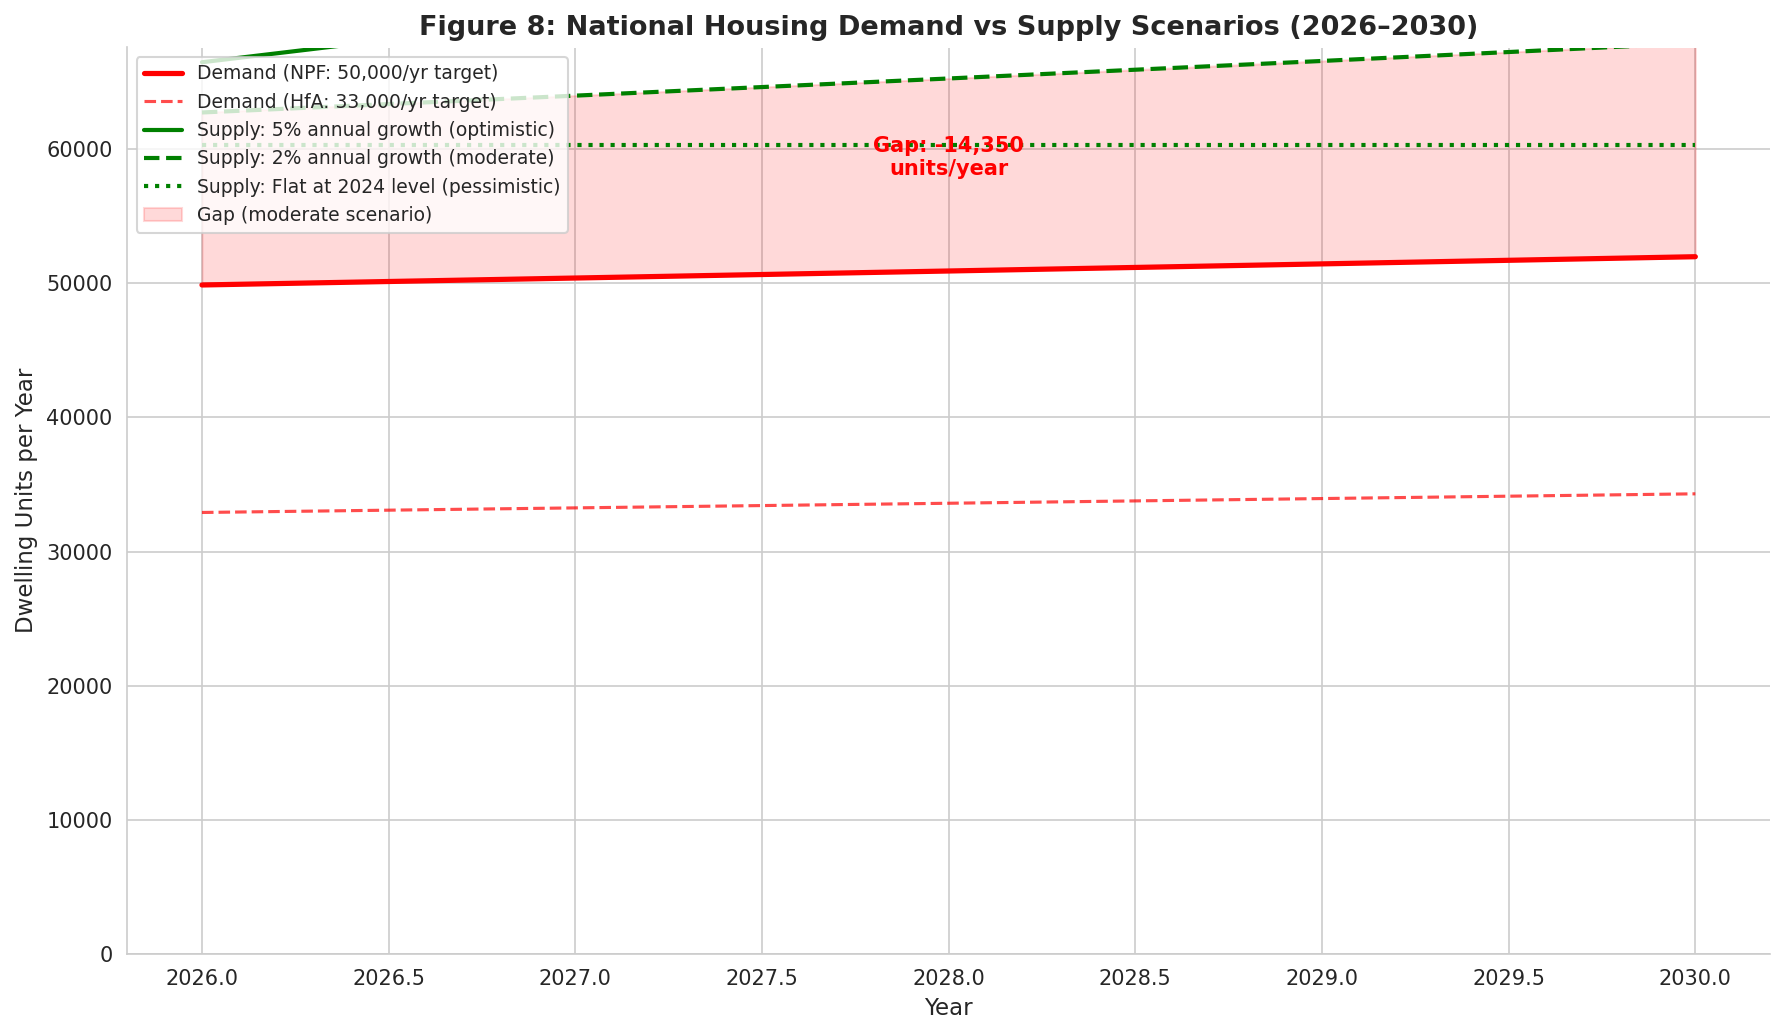

✅ Figure 8 saved

Gap under moderate (2%) supply growth:
  2026: -12,858 units/year SURPLUS
  2027: -13,594 units/year SURPLUS
  2028: -14,350 units/year SURPLUS
  2029: -15,125 units/year SURPLUS
  2030: -15,922 units/year SURPLUS


In [ ]:
# ============================================================
# FIGURE 8: National Gap Under Different Scenarios
# ============================================================

years = list(range(2026, 2031))
national_demand_npf = national_gaps['demand_npf'].values

# Three supply scenarios
supply_base = national_gaps['supply'].values  # 5% growth (optimistic)
supply_flat = [supply_2024['supply_2024'].sum() * (1.00 ** (y - 2024)) for y in years]  # Flat
supply_slow = [supply_2024['supply_2024'].sum() * (1.02 ** (y - 2024)) for y in years]  # 2% growth

gap_optimistic = national_demand_npf - supply_base
gap_flat = national_demand_npf - np.array(supply_flat)
gap_slow = national_demand_npf - np.array(supply_slow)

fig, ax = plt.subplots(figsize=(12, 7))

# Demand line
ax.plot(years, national_demand_npf, 'r-', linewidth=2.5, label='Demand (NPF: 50,000/yr target)')
ax.plot(years, [national_gaps['demand_hfa'].values[i] for i in range(5)], 'r--', linewidth=1.5,
        label='Demand (HfA: 33,000/yr target)', alpha=0.7)

# Supply scenarios
ax.plot(years, supply_base, 'g-', linewidth=2, label='Supply: 5% annual growth (optimistic)')
ax.plot(years, supply_slow, 'g--', linewidth=2, label='Supply: 2% annual growth (moderate)')
ax.plot(years, supply_flat, 'g:', linewidth=2, label='Supply: Flat at 2024 level (pessimistic)')

# Shade the gap for moderate scenario
ax.fill_between(years, national_demand_npf, supply_slow, alpha=0.15, color='red', label='Gap (moderate scenario)')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Dwelling Units per Year', fontsize=11)
ax.set_title('Figure 8: National Housing Demand vs Supply Scenarios (2026–2030)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, max(national_demand_npf) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add gap annotations
mid_year = 2028
mid_idx = 2
ax.annotate(f'Gap: {gap_slow[mid_idx]:,.0f}\nunits/year',
            xy=(mid_year, (national_demand_npf[mid_idx] + supply_slow[mid_idx])/2),
            fontsize=10, ha='center', fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('/content/fig8_scenario_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 8 saved")
print(f"\nGap under moderate (2%) supply growth:")
for y, g in zip(years, gap_slow):
    print(f"  {y}: {g:,.0f} units/year {'SHORTAGE' if g > 0 else 'SURPLUS'}")

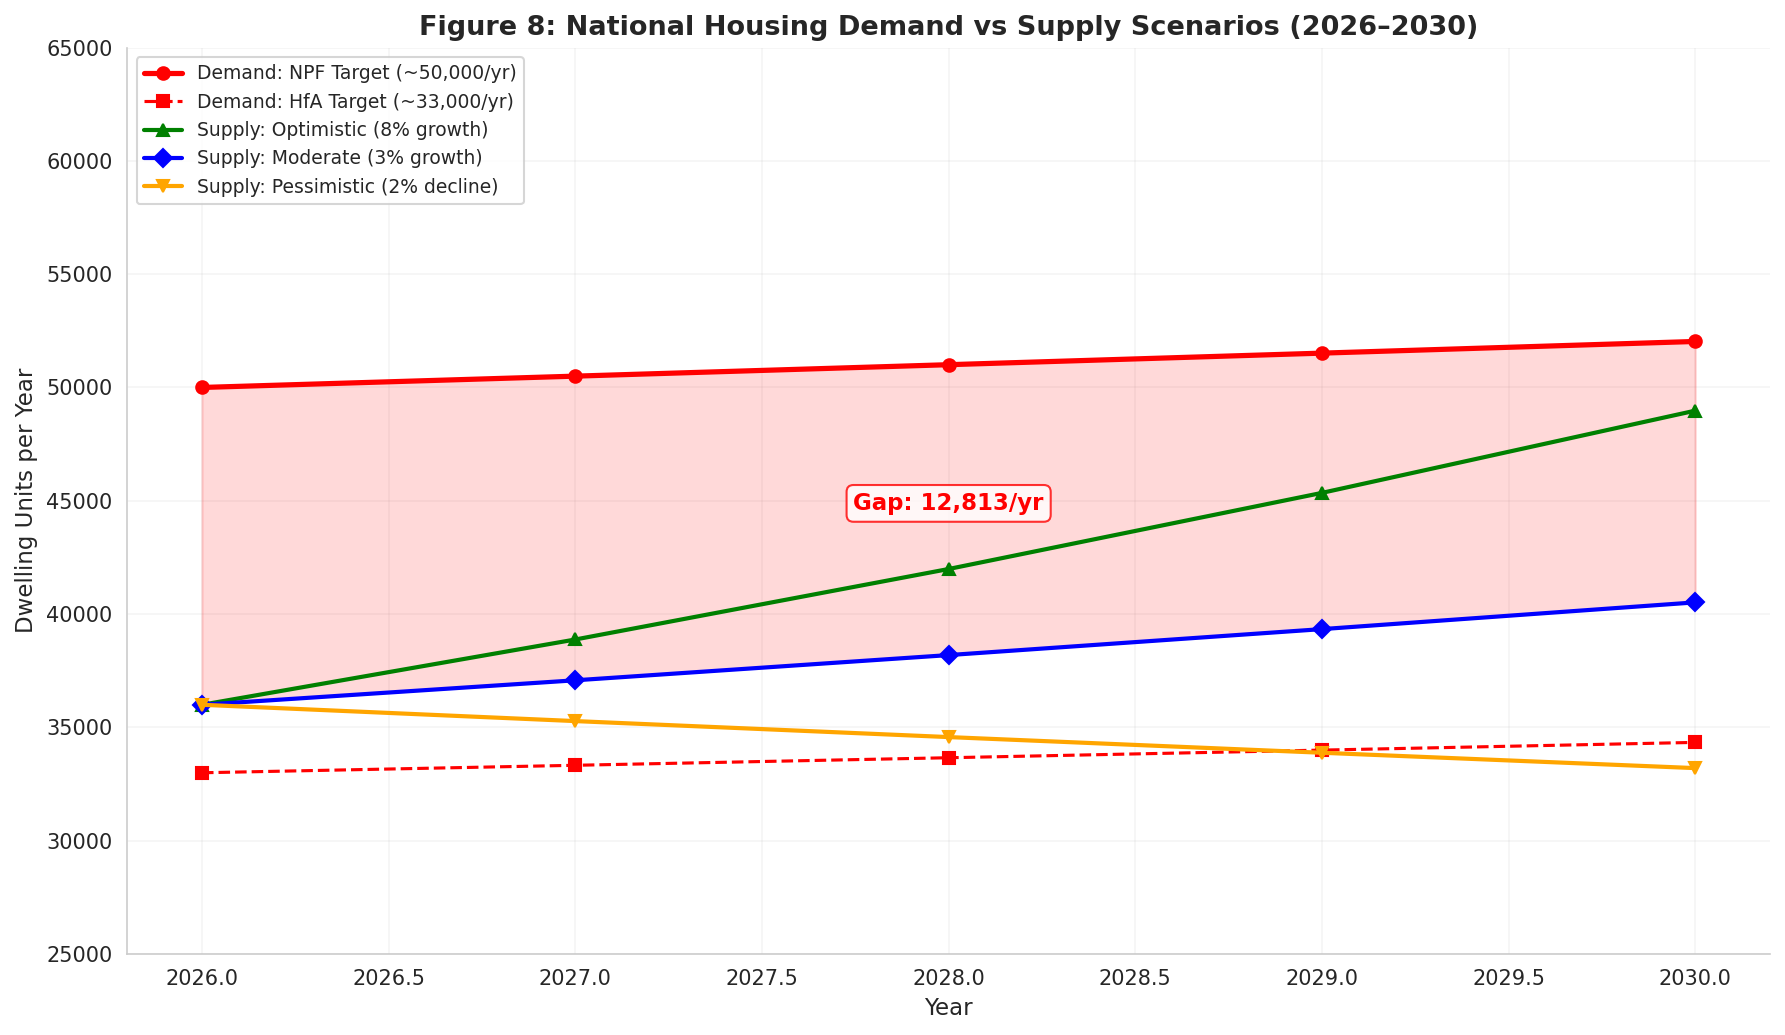

✅ Figure 8 saved


In [ ]:
# ============================================================
# FIGURE 8 (FIXED): Cleaner Scenario Chart
# ============================================================

years = list(range(2026, 2031))

# Demand scenarios
demand_hfa = [33000 * (1.01 ** (y-2026)) for y in years]  # HfA + 1% pop growth
demand_npf = [50000 * (1.01 ** (y-2026)) for y in years]  # NPF + 1% pop growth

# Supply scenarios — start from ESRI forecast of 36,000 for 2026
supply_optimistic = [36000 * (1.08 ** (y-2026)) for y in years]  # 8% growth
supply_moderate = [36000 * (1.03 ** (y-2026)) for y in years]    # 3% growth
supply_pessimistic = [36000 * (0.98 ** (y-2026)) for y in years] # 2% decline (commencements dropped)

fig, ax = plt.subplots(figsize=(12, 7))

# Demand
ax.plot(years, demand_npf, 'r-', linewidth=2.5, marker='o', label='Demand: NPF Target (~50,000/yr)')
ax.plot(years, demand_hfa, 'r--', linewidth=1.5, marker='s', label='Demand: HfA Target (~33,000/yr)')

# Supply
ax.plot(years, supply_optimistic, 'g-', linewidth=2, marker='^', label='Supply: Optimistic (8% growth)')
ax.plot(years, supply_moderate, 'b-', linewidth=2, marker='D', label='Supply: Moderate (3% growth)')
ax.plot(years, supply_pessimistic, color='orange', linewidth=2, marker='v', label='Supply: Pessimistic (2% decline)')

# Shade gap between NPF demand and moderate supply
ax.fill_between(years, demand_npf, supply_moderate, alpha=0.15, color='red')

# Annotate gap
for i, y in enumerate(years):
    if y == 2028:
        gap = demand_npf[i] - supply_moderate[i]
        mid = (demand_npf[i] + supply_moderate[i]) / 2
        ax.annotate(f'Gap: {gap:,.0f}/yr', xy=(y, mid), fontsize=11,
                    ha='center', fontweight='bold', color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Dwelling Units per Year', fontsize=11)
ax.set_title('Figure 8: National Housing Demand vs Supply Scenarios (2026–2030)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(25000, 65000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('/content/fig8_scenario_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 8 saved")

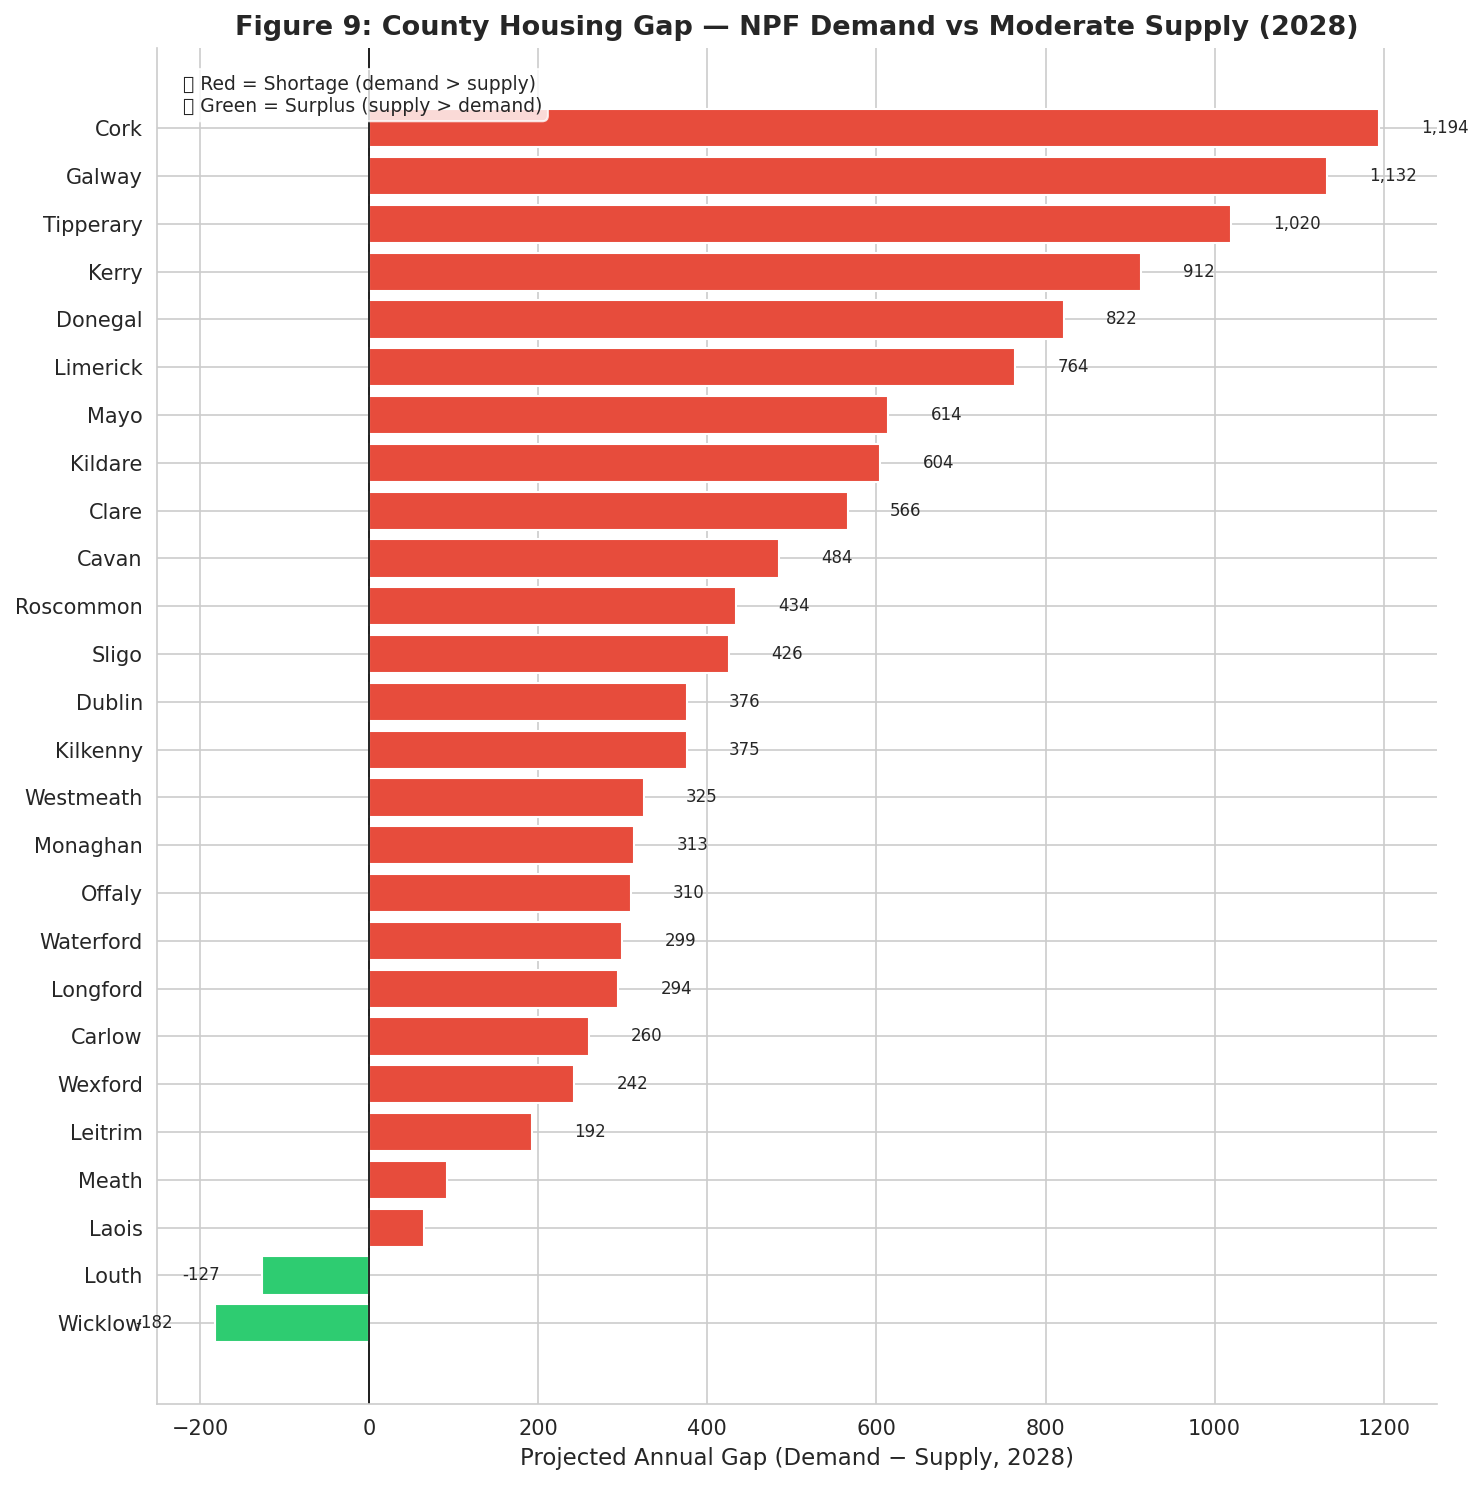

✅ Figure 9 saved


In [ ]:
# ============================================================
# FIGURE 9: County Risk Ranking — Gap Under Moderate Scenario
# ============================================================

# Recalculate gaps using ESRI-based supply estimates
county_2024 = master[master['year'] == 2024].groupby('county').agg(
    completions_2024=('completions', 'sum'),
    population=('population', 'mean')
).reset_index()

# Demand per county = county share of national population × 50,000
total_pop = county_2024['population'].sum()
county_2024['demand_npf'] = (county_2024['population'] / total_pop) * 50000
county_2024['demand_hfa'] = (county_2024['population'] / total_pop) * 33000

# Supply projection: moderate 3% growth from ESRI 36,000 base
# Distribute nationally proportional to 2024 completions
total_comp_2024 = county_2024['completions_2024'].sum()
county_2024['supply_2028'] = (county_2024['completions_2024'] / total_comp_2024) * (36000 * 1.03**2)

# Gap = demand - supply (positive = shortage)
county_2024['gap_npf'] = county_2024['demand_npf'] - county_2024['supply_2028']
county_2024 = county_2024.sort_values('gap_npf', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if g > 0 else '#2ecc71' for g in county_2024['gap_npf']]
ax.barh(county_2024['county'], county_2024['gap_npf'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Projected Annual Gap (Demand − Supply, 2028)', fontsize=11)
ax.set_title('Figure 9: County Housing Gap — NPF Demand vs Moderate Supply (2028)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add labels
for i, (county, gap) in enumerate(zip(county_2024['county'], county_2024['gap_npf'])):
    if abs(gap) > 100:
        ax.text(gap + (50 if gap > 0 else -50), i, f'{gap:,.0f}',
                va='center', ha='left' if gap > 0 else 'right', fontsize=8)

# Legend
ax.text(0.02, 0.98, '🔴 Red = Shortage (demand > supply)\n🟢 Green = Surplus (supply > demand)',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/fig9_county_gap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 9 saved")

In [ ]:
# ============================================================
# TABLE 1: Final Model Comparison Table (for paper)
# ============================================================

print("=" * 70)
print("TABLE: Model Performance Comparison")
print("=" * 70)
print(f"{'Model':<20} {'Mean MAE':>10} {'Median MAE':>12} {'Std':>8} {'vs Best (%)':>12}")
print("-" * 70)

models_ordered = ['Seasonal_Naive', 'ETS', 'SARIMA', 'XGBoost', 'Naive', 'LightGBM']
best_mean = summary['mean'].min()
best_median = summary['median'].min()

for model in models_ordered:
    row = summary.loc[model]
    print(f"{model:<20} {row['mean']:>10.1f} {row['median']:>12.1f} {row['std']:>8.1f} {row['vs_seasonal_naive']:>11.1f}%")

print("-" * 70)
print(f"\n✅ Best by Mean MAE: Seasonal Naïve ({summary['mean'].min():.1f})")
print(f"✅ Best by Median MAE: ETS ({summary['median'].min():.1f})")

# ============================================================
# SUMMARY OF ALL FIGURES CREATED
# ============================================================
print("\n" + "=" * 70)
print("ALL OUTPUTS CREATED")
print("=" * 70)
print("""
FIGURES:
  Fig 1: National Housing Pipeline (2011-2025)     ✅
  Fig 2: County Delivery Intensity (2024)           ✅
  Fig 3: Permission-Completion Lag Analysis          ✅
  Fig 4: Feature Correlation Heatmap                 ✅
  Fig 5: Model Comparison (Mean vs Median MAE)       ✅
  Fig 6: SHAP Global Feature Importance              ✅
  Fig 7: SHAP Waterfall (Dublin vs Leitrim)          ✅
  Fig 8: National Demand vs Supply Scenarios         ✅
  Fig 9: County Gap Ranking (2028)                   ✅

DATASETS:
  master_dataset.csv                                 ✅
  gap_projections.csv                                ✅

MODELS TRAINED:
  Naive, Seasonal Naive, ETS, SARIMA, XGBoost, LightGBM  ✅

KEY FINDINGS FOR PAPER:
  1. Seasonal Naïve wins on mean MAE — simple models suit small quarterly data
  2. ETS and XGBoost win on median MAE — better for typical counties
  3. SHAP: Lagged completions, population, and rent are top drivers
  4. Commencements validate the 3-stage pipeline (Permission→Commence→Complete)
  5. National gap of ~12,800 units/yr under moderate supply growth
  6. Cork, Galway, Tipperary face largest county-level shortages
  7. 2025 commencement drop signals supply risk for 2026-2027
""")

TABLE: Model Performance Comparison
Model                  Mean MAE   Median MAE      Std  vs Best (%)
----------------------------------------------------------------------
Seasonal_Naive            154.8         94.6    237.7         0.0%
ETS                       165.2         80.8    307.0         6.7%
SARIMA                    175.1         84.0    323.6        13.1%
XGBoost                   194.9         85.2    337.6        25.9%
Naive                     232.4        102.1    471.6        50.1%
LightGBM                  259.8        156.2    420.0        67.8%
----------------------------------------------------------------------

✅ Best by Mean MAE: Seasonal Naïve (154.8)
✅ Best by Median MAE: ETS (80.8)

ALL OUTPUTS CREATED

FIGURES:
  Fig 1: National Housing Pipeline (2011-2025)     ✅
  Fig 2: County Delivery Intensity (2024)           ✅
  Fig 3: Permission-Completion Lag Analysis          ✅
  Fig 4: Feature Correlation Heatmap                 ✅
  Fig 5: Model Comparison (M

In [ ]:
# ============================================================
# ROLLING-ORIGIN CROSS-VALIDATION
# ============================================================
# Instead of one fixed train/test split, we move the cutoff
# forward 4 times and average results across all origins.
# Origins: 2022Q1, 2022Q3, 2023Q1, 2023Q3
# Each time we forecast 4 quarters ahead
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

FEATURES = ['completions_lag1', 'completions_lag2', 'completions_lag3', 'completions_lag4',
            'permissions_lag3', 'permissions_lag4', 'permissions_lag5',
            'commencements_lag3', 'commencements_lag4',
            'population', 'avg_rent', 'income_per_person',
            'property_price_index', 'quarter_num']

origins = ['2022-01-01', '2022-07-01', '2023-01-01', '2023-07-01']
horizon = 4  # forecast 4 quarters ahead

rolling_results = []

for origin in origins:
    print(f"\n--- Origin: {origin} ---")

    train_ro = master[master['date'] < origin].copy()
    test_ro = master[(master['date'] >= origin) &
                     (master['date'] < pd.Timestamp(origin) + pd.DateOffset(months=12))].copy()

    if len(test_ro) == 0:
        continue

    print(f"  Train: {len(train_ro)} rows, Test: {len(test_ro)} rows")

    for county in master['county'].unique():
        ct_train = train_ro[train_ro['county'] == county].sort_values('date')
        ct_test = test_ro[test_ro['county'] == county].sort_values('date')

        if len(ct_test) == 0 or len(ct_train) < 8:
            continue

        actuals = ct_test['completions'].values
        n_test = len(actuals)

        # 1. Naive
        naive_pred = np.full(n_test, ct_train['completions'].iloc[-1])
        rolling_results.append({'origin': origin, 'county': county, 'model': 'Naive',
                               'MAE': mean_absolute_error(actuals, naive_pred)})

        # 2. Seasonal Naive
        s_pred = []
        for _, row in ct_test.iterrows():
            q = row['date'].quarter
            same_q = ct_train[ct_train['date'].dt.quarter == q]['completions']
            s_pred.append(same_q.iloc[-1] if len(same_q) > 0 else ct_train['completions'].iloc[-1])
        rolling_results.append({'origin': origin, 'county': county, 'model': 'Seasonal_Naive',
                               'MAE': mean_absolute_error(actuals, s_pred)})

        # 3. ETS
        try:
            ts = ct_train.set_index('date')['completions'].copy()
            ts.index.freq = 'QS'
            ets = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=4).fit(optimized=True)
            ets_pred = np.clip(ets.forecast(n_test).values, 0, None)
            rolling_results.append({'origin': origin, 'county': county, 'model': 'ETS',
                                   'MAE': mean_absolute_error(actuals, ets_pred)})
        except:
            pass

        # 4. SARIMA
        try:
            ts = ct_train.set_index('date')['completions'].copy()
            ts.index.freq = 'QS'
            sarima = auto_arima(ts, seasonal=True, m=4, stepwise=True, suppress_warnings=True,
                               max_p=2, max_q=2, max_P=1, max_Q=1, max_d=1, max_D=1, error_action='ignore')
            sarima_pred = np.clip(sarima.predict(n_periods=n_test), 0, None)
            rolling_results.append({'origin': origin, 'county': county, 'model': 'SARIMA',
                                   'MAE': mean_absolute_error(actuals, sarima_pred)})
        except:
            pass

    # 5. XGBoost (pooled across counties)
    tr_ml = train_ro.dropna(subset=['completions_lag4']).copy()
    te_ml = test_ro.copy()
    for col in FEATURES:
        tr_ml[col] = tr_ml[col].fillna(0)
        te_ml[col] = te_ml[col].fillna(0)

    if len(tr_ml) > 50 and len(te_ml) > 0:
        xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, random_state=42)
        xgb.fit(tr_ml[FEATURES], tr_ml['completions'])
        xgb_pred = np.clip(xgb.predict(te_ml[FEATURES]), 0, None)

        lgb = LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
        lgb.fit(tr_ml[FEATURES], tr_ml['completions'])
        lgb_pred = np.clip(lgb.predict(te_ml[FEATURES]), 0, None)

        for county in te_ml['county'].unique():
            mask = te_ml['county'] == county
            if mask.sum() > 0:
                rolling_results.append({'origin': origin, 'county': county, 'model': 'XGBoost',
                                       'MAE': mean_absolute_error(te_ml.loc[mask, 'completions'], xgb_pred[mask])})
                rolling_results.append({'origin': origin, 'county': county, 'model': 'LightGBM',
                                       'MAE': mean_absolute_error(te_ml.loc[mask, 'completions'], lgb_pred[mask])})

rolling_df = pd.DataFrame(rolling_results)

# Average across all origins
rolling_summary = rolling_df.groupby('model')['MAE'].agg(['mean', 'median', 'std']).round(1)
rolling_summary = rolling_summary.sort_values('mean')

print("\n" + "=" * 60)
print("ROLLING-ORIGIN CROSS-VALIDATION RESULTS")
print("(Averaged across 4 origins × 26 counties)")
print("=" * 60)
print(rolling_summary.to_string())
print(f"\nBest by Mean: {rolling_summary.index[0]}")
print(f"Best by Median: {rolling_summary['median'].idxmin()}")


--- Origin: 2022-01-01 ---
  Train: 1144 rows, Test: 104 rows

--- Origin: 2022-07-01 ---
  Train: 1196 rows, Test: 104 rows

--- Origin: 2023-01-01 ---
  Train: 1248 rows, Test: 104 rows

--- Origin: 2023-07-01 ---
  Train: 1300 rows, Test: 104 rows

ROLLING-ORIGIN CROSS-VALIDATION RESULTS
(Averaged across 4 origins × 26 counties)
                 mean  median    std
model                               
ETS             141.3    61.1  276.9
Naive           151.2    75.5  254.3
XGBoost         155.5    62.1  362.9
SARIMA          161.6    64.7  300.5
Seasonal_Naive  166.5    79.8  310.9
LightGBM        181.3    82.9  362.5

Best by Mean: ETS
Best by Median: ETS


In [ ]:
# ============================================================
# HEADSHIP-RATE DEMAND ESTIMATION
# ============================================================
# Headship rate = % of people who head a household
# Ireland 2022: ~38% (suppressed by housing crisis)
# UK 2022: ~42% (benchmark for convergence)
#
# We project demand under 3 scenarios:
# 1. Constant headship (38%) — baseline
# 2. Gradual convergence to UK (42%) by 2030 — moderate
# 3. Full convergence to UK by 2028 — aggressive
# ============================================================

IRISH_HEADSHIP_2022 = 0.38
UK_HEADSHIP_2022 = 0.42
AVG_HOUSEHOLD_SIZE_IRELAND = 2.7  # CSO Census 2022

# Get county populations for 2022
pop_2022 = master[master['year'] == 2022].groupby('county')['population'].mean().reset_index()

# Population growth rates for projection
pop_growth = master[master['year'].between(2018, 2023)].groupby('county').apply(
    lambda x: x.set_index('date')['population'].pct_change(4).mean()
).reset_index(name='annual_growth')
pop_growth['annual_growth'] = pop_growth['annual_growth'].fillna(0.01)

# Merge
pop_2022 = pop_2022.merge(pop_growth, on='county')

# Project demand under 3 headship scenarios
headship_results = []

for _, row in pop_2022.iterrows():
    county = row['county']
    pop_base = row['population']
    growth = row['annual_growth']

    for year in range(2026, 2031):
        years_ahead = year - 2022
        projected_pop = pop_base * (1 + growth) ** years_ahead

        # Scenario 1: Constant headship (38%)
        households_constant = projected_pop * IRISH_HEADSHIP_2022
        # New households needed = change from previous year
        prev_pop = pop_base * (1 + growth) ** (years_ahead - 1)
        new_hh_constant = (projected_pop - prev_pop) * IRISH_HEADSHIP_2022
        # Plus replacement (obsolescence ~0.5% of stock)
        existing_stock = pop_base * IRISH_HEADSHIP_2022 / 1  # approximate
        replacement = existing_stock * 0.005
        demand_constant = new_hh_constant + replacement

        # Scenario 2: Gradual convergence (linear from 38% to 42% by 2030)
        t = min((year - 2022) / (2030 - 2022), 1.0)
        headship_gradual = IRISH_HEADSHIP_2022 + (UK_HEADSHIP_2022 - IRISH_HEADSHIP_2022) * t
        households_gradual = projected_pop * headship_gradual
        prev_hh_gradual = prev_pop * (IRISH_HEADSHIP_2022 + (UK_HEADSHIP_2022 - IRISH_HEADSHIP_2022) * max(t - 1/(2030-2022), 0))
        new_hh_gradual = households_gradual - prev_hh_gradual
        demand_gradual = new_hh_gradual + replacement

        # Scenario 3: Aggressive convergence (reach 42% by 2028)
        t_fast = min((year - 2022) / (2028 - 2022), 1.0)
        headship_fast = IRISH_HEADSHIP_2022 + (UK_HEADSHIP_2022 - IRISH_HEADSHIP_2022) * t_fast
        households_fast = projected_pop * headship_fast
        prev_hh_fast = prev_pop * (IRISH_HEADSHIP_2022 + (UK_HEADSHIP_2022 - IRISH_HEADSHIP_2022) * max((years_ahead-1-0)/(2028-2022), 0))
        new_hh_fast = households_fast - prev_hh_fast
        demand_fast = new_hh_fast + replacement

        headship_results.append({
            'county': county,
            'year': year,
            'projected_population': projected_pop,
            'headship_constant': IRISH_HEADSHIP_2022,
            'headship_gradual': headship_gradual,
            'headship_aggressive': headship_fast,
            'demand_constant': max(demand_constant, 0),
            'demand_gradual': max(demand_gradual, 0),
            'demand_aggressive': max(demand_fast, 0),
        })

headship_df = pd.DataFrame(headship_results)

# National summary
national_headship = headship_df.groupby('year').agg(
    demand_constant=('demand_constant', 'sum'),
    demand_gradual=('demand_gradual', 'sum'),
    demand_aggressive=('demand_aggressive', 'sum')
).round(0)

print("=" * 60)
print("HEADSHIP-RATE DEMAND PROJECTIONS (National)")
print("=" * 60)
print(national_headship.to_string())
print()
print(f"Constant headship avg annual demand: {national_headship['demand_constant'].mean():,.0f}")
print(f"Gradual convergence avg annual demand: {national_headship['demand_gradual'].mean():,.0f}")
print(f"Aggressive convergence avg annual demand: {national_headship['demand_aggressive'].mean():,.0f}")

headship_df.to_csv('/content/headship_demand_projections.csv', index=False)
print("\n✅ Headship demand projections saved")

HEADSHIP-RATE DEMAND PROJECTIONS (National)
      demand_constant  demand_gradual  demand_aggressive
year                                                    
2026          30743.0         58401.0            67620.0
2027          30970.0         59195.0            68604.0
2028          31201.0         60001.0            69602.0
2029          31434.0         60820.0            33713.0
2030          31669.0         61650.0              952.0

Constant headship avg annual demand: 31,203
Gradual convergence avg annual demand: 60,013
Aggressive convergence avg annual demand: 48,098

✅ Headship demand projections saved


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

train_data = master[master['date'] <= '2023-12-31']
test_data = master[master['date'] > '2023-12-31']

# Step 1: Forecast each county independently with ETS
county_forecasts = {}
for county in master['county'].unique():
    ct = train_data[train_data['county'] == county].sort_values('date').set_index('date')['completions']
    try:
        ct.index.freq = 'QS'
        model = ExponentialSmoothing(ct, trend='add', seasonal='add', seasonal_periods=4).fit(optimized=True)
        forecast = model.forecast(8)
        county_forecasts[county] = np.clip(forecast.values, 0, None)
    except:
        county_forecasts[county] = np.full(8, ct.iloc[-4:].mean())

# Step 2: National ETS forecast
national_train = train_data.groupby('date')['completions'].sum()
national_train.index.freq = 'QS'
national_model = ExponentialSmoothing(national_train, trend='add', seasonal='add', seasonal_periods=4).fit(optimized=True)
national_forecast = np.clip(national_model.forecast(8).values, 0, None)

# Step 3: Check sum before reconciliation
county_sum = np.zeros(8)
for county, fc in county_forecasts.items():
    county_sum += fc

print("BEFORE RECONCILIATION:")
print(f"  National ETS forecast (Q avg): {national_forecast.mean():.0f}")
print(f"  Sum of county forecasts (Q avg): {county_sum.mean():.0f}")
print(f"  Difference: {(county_sum.mean() - national_forecast.mean()):.0f}")

# Step 4: Reconcile
reconciled_forecasts = {}
for county, fc in county_forecasts.items():
    scale_factor = national_forecast / county_sum
    reconciled_forecasts[county] = fc * scale_factor

reconciled_sum = np.zeros(8)
for county, fc in reconciled_forecasts.items():
    reconciled_sum += fc

print(f"\nAFTER RECONCILIATION:")
print(f"  National forecast: {national_forecast.mean():.0f}")
print(f"  Sum of reconciled: {reconciled_sum.mean():.0f}")

# Step 5: Compare accuracy
unreconciled_mae = []
reconciled_mae = []

for county in master['county'].unique():
    ct_test = test_data[test_data['county'] == county].sort_values('date')['completions'].values
    n = min(len(ct_test), 8)
    if n == 0:
        continue
    unrec = county_forecasts[county][:n]
    rec = reconciled_forecasts[county][:n]
    actual = ct_test[:n]
    unreconciled_mae.append(mean_absolute_error(actual, unrec))
    reconciled_mae.append(mean_absolute_error(actual, rec))

print(f"\nACCURACY COMPARISON:")
print(f"  Unreconciled ETS avg MAE: {np.mean(unreconciled_mae):.1f}")
print(f"  Reconciled ETS avg MAE:   {np.mean(reconciled_mae):.1f}")
improvement = (np.mean(unreconciled_mae) - np.mean(reconciled_mae)) / np.mean(unreconciled_mae) * 100
print(f"  Improvement: {improvement:.1f}%")
print("\n✅ Hierarchical reconciliation complete")

BEFORE RECONCILIATION:
  National ETS forecast (Q avg): 19222
  Sum of county forecasts (Q avg): 19174
  Difference: -48

AFTER RECONCILIATION:
  National forecast: 19222
  Sum of reconciled: 19222

ACCURACY COMPARISON:
  Unreconciled ETS avg MAE: 165.2
  Reconciled ETS avg MAE:   161.7
  Improvement: 2.2%

✅ Hierarchical reconciliation complete


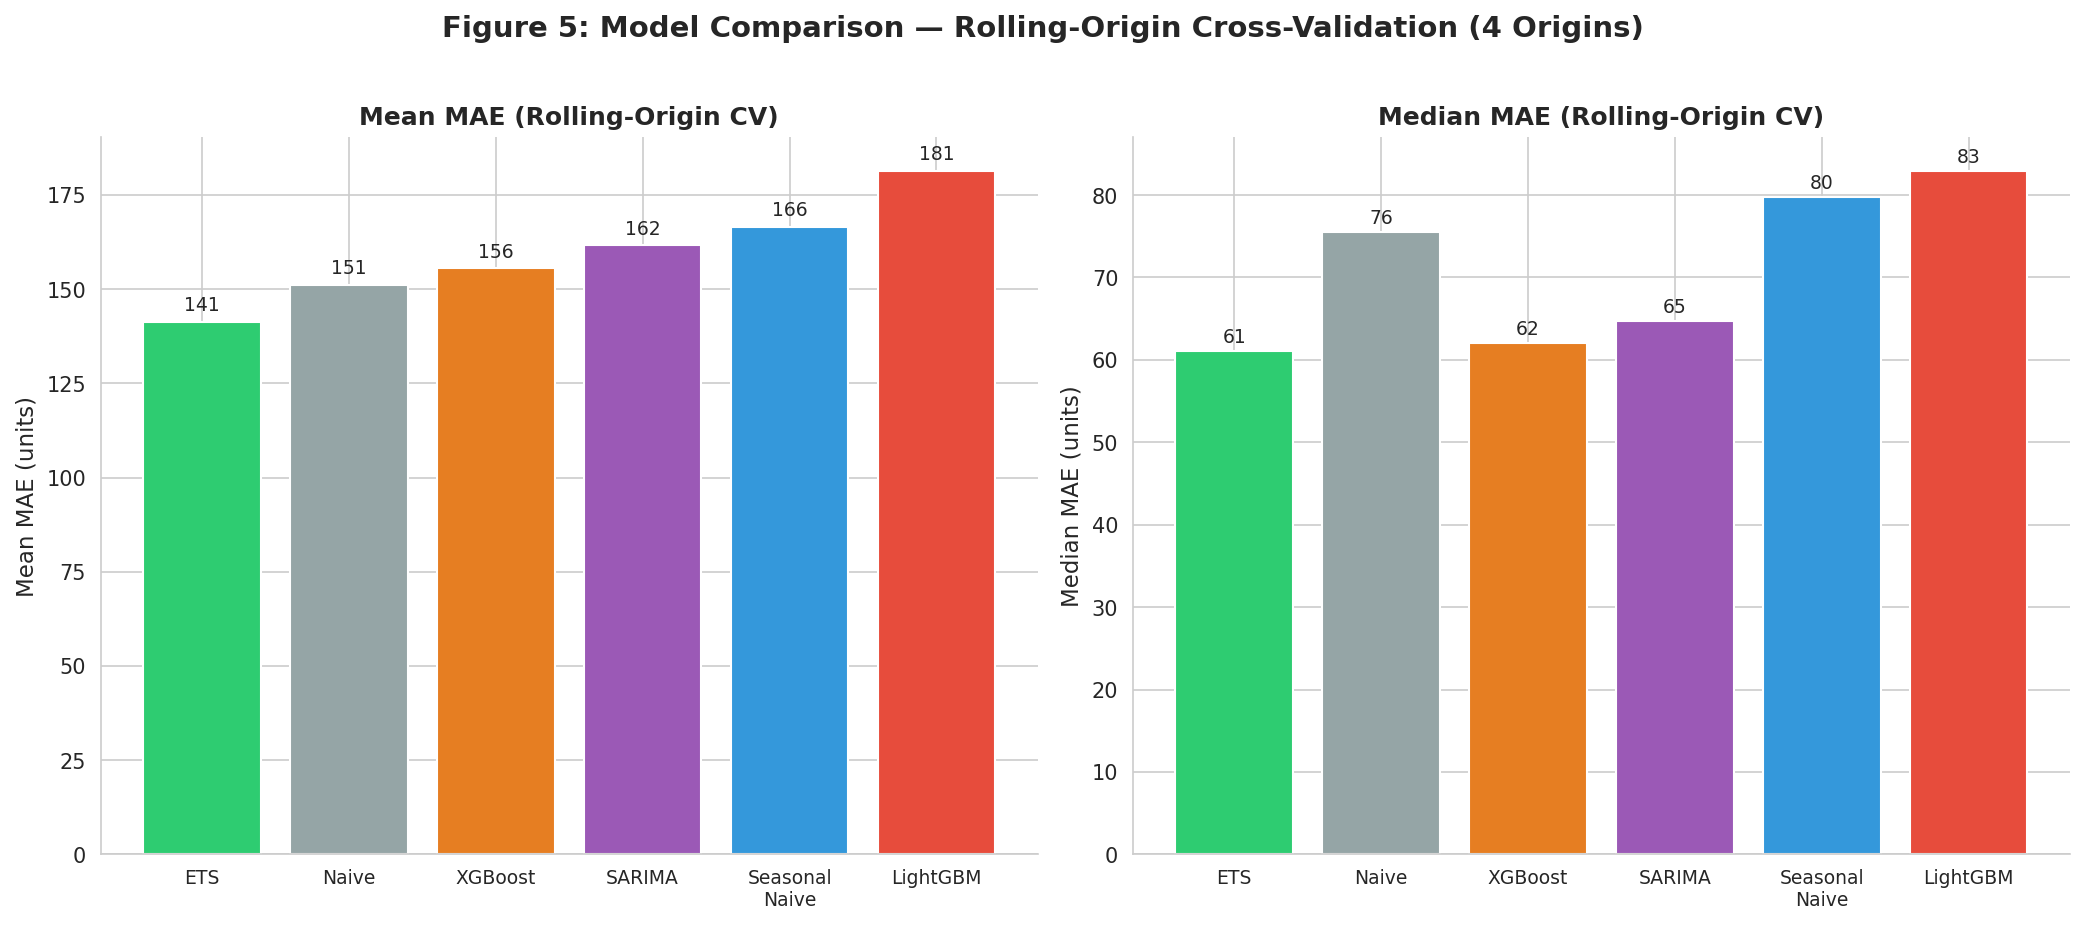

✅ Figure 5 updated with rolling-origin results


In [ ]:
# ============================================================
# FIGURE 5 (UPDATED): Model Comparison with Rolling-Origin Results
# ============================================================

rolling_summary = rolling_df.groupby('model')['MAE'].agg(['mean', 'median', 'std']).round(1)
rolling_summary = rolling_summary.sort_values('mean')

model_order = rolling_summary.index.tolist()
colors_map = {
    'ETS': '#2ecc71', 'Naive': '#95a5a6', 'XGBoost': '#e67e22',
    'SARIMA': '#9b59b6', 'Seasonal_Naive': '#3498db', 'LightGBM': '#e74c3c'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

means = [rolling_summary.loc[m, 'mean'] for m in model_order]
medians = [rolling_summary.loc[m, 'median'] for m in model_order]
colors = [colors_map[m] for m in model_order]

bars1 = ax1.bar(range(len(model_order)), means, color=colors)
ax1.set_xticks(range(len(model_order)))
ax1.set_xticklabels([m.replace('_', '\n') for m in model_order], fontsize=9)
ax1.set_ylabel('Mean MAE (units)', fontsize=11)
ax1.set_title('Mean MAE (Rolling-Origin CV)', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f'{val:.0f}', ha='center', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

bars2 = ax2.bar(range(len(model_order)), medians, color=colors)
ax2.set_xticks(range(len(model_order)))
ax2.set_xticklabels([m.replace('_', '\n') for m in model_order], fontsize=9)
ax2.set_ylabel('Median MAE (units)', fontsize=11)
ax2.set_title('Median MAE (Rolling-Origin CV)', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, medians):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.0f}', ha='center', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure 5: Model Comparison — Rolling-Origin Cross-Validation (4 Origins)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/fig5_model_comparison_updated.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 5 updated with rolling-origin results")